# 🪨📄✂️ Rock-Paper-Scissors Behavior Cloning
### A transformer that predicts the next move

## 1. Setup

### Imports

In [ ]:
import sys

import torch
import torch.nn as nn
from torch.nn import functional as F
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm
from collections import Counter
from pathlib import Path
from urllib.request import urlretrieve
from collections import defaultdict


### Constants and parameters

In [ ]:
SEED = 31416
MOVE={'rock':0,'paper':1,'scissors':2, 'none': -1}
NAMES = ['rock', 'paper', 'scissors']
SYM = ['🪨', '📄', '✂️']
OUTCOME = {'loss': -1, 'tie': 0, 'win': 1}
OUTCOME_NAMES = ['loss', 'tie', 'win']
POINTS = {'loss': -1, 'tie': 0, 'win': 3}

# locations of the Brockbank RPS datasets
# v1 = human vs human dyads
# v2 = human vs stable bots
# v3 = human vs adaptive bots
DATA_SOURCES = [
    {
        'source': 'v1',
        'cache_name': 'rps_v1_data.csv',
        'urls': [
            'https://raw.githubusercontent.com/erik-brockbank/rps-games-analysis/main/data/rps_v1_data.csv',
            'https://raw.githubusercontent.com/erik-brockbank/rps-games-analysis/master/data/rps_v1_data.csv',
        ],
        'read_csv_kwargs': {},
    },
    {
        'source': 'v2',
        'cache_name': 'rps_v2_data.csv.zip',
        'urls': [
            'https://raw.githubusercontent.com/erik-brockbank/rps/master/analysis/rps_v2_data.csv.zip',
        ],
        'read_csv_kwargs': {'compression': 'zip'},
    },
    {
        'source': 'v3',
        'cache_name': 'rps_v3_data.csv',
        'urls': [
            'https://raw.githubusercontent.com/erik-brockbank/rps/master/analysis/rps_v3_data.csv',
        ],
        'read_csv_kwargs': {},
    },
]

# cache Brockbank source files locally so we do not need to re-download them every run
DATA_CACHE_DIR = Path('rps_brockbank_data')

model_params = {
    'context_length': 8, # how many past rounds the model can see
    'batch_size': 64,
    'd_embed': 96,
    'n_head': 4,
    'n_layer': 2,
    'dropout': 0.2,
    'learning_rate': 3e-3,
    'weight_decay': 1e-2,
    'n_epochs': 30,
    'd_input': None, # per-round feature dim (moves/outcomes, and optionally totals), set after dataset is created
    'include_totals': True, # if False, ignore running score totals as an input feature
    'n_player_ids': None, # to be set after dataset is created
    'd_output': len(NAMES), # 3-class one-hot for the next move
    'scheduler_type': 'OneCycleLR', # learning rate scheduler to use during training
    'early_stopping_patience': 5, # stop if holdout loss does not improve for this many epochs
}

lr_scheduler_params = {
    'max_lr': 3e-3,
    'epochs': model_params['n_epochs'],
    'pct_start': 0.3,
    'anneal_strategy': 'cos',
    'div_factor': 25.0,
    'final_div_factor': 1e4,    
}

holdout_fraction = .1 # fraction of target rounds from each game used for holdout / early stopping
test_fraction = .1 # fraction of target rounds from each game reserved for the final test set

torch.manual_seed(SEED)
np.random.seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)


device: cpu


## 2. Load and process the data

### Load the data

In [ ]:
# load and normalize the Brockbank datasets

DATA_CACHE_DIR.mkdir(exist_ok=True)

def load_source_dataframe(spec):
    cache_path = DATA_CACHE_DIR / spec['cache_name']

    if not cache_path.exists():
        last_error = None
        for url in spec['urls']:
            try:
                urlretrieve(url, cache_path)
                print(f"Downloaded {spec['source']} to {cache_path}")
                break
            except Exception as exc:
                last_error = exc
        else:
            raise last_error
    else:
        print(f"Using cached copy for {spec['source']}: {cache_path}")

    return pd.read_csv(cache_path, **spec.get('read_csv_kwargs', {}))

def normalize_source_dataframe(df_source, source_name):
    """Map one source dataframe to the canonical columns used by the notebook."""
    required_columns = ['game_id', 'round_index', 'player_id', 'player_move', 'player_outcome', 'player_points']
    missing = [col for col in required_columns if col not in df_source.columns]
    if missing:
        raise ValueError(f"Source {source_name} is missing required columns: {missing}")

    df_norm = df_source.copy()
    df_norm['source'] = source_name
    df_norm['game_id'] = source_name + ':' + df_norm['game_id'].astype(str)

    if 'is_bot' in df_norm.columns:
        df_norm['is_bot'] = df_norm['is_bot'].fillna(0).astype(int)
    else:
        df_norm['is_bot'] = 0

    if 'bot_strategy' in df_norm.columns:
        df_norm['bot_strategy'] = df_norm['bot_strategy'].fillna('')
    else:
        df_norm['bot_strategy'] = ''

    # Human rows keep their individual ids with a source prefix.
    human_mask = df_norm['is_bot'] == 0
    df_norm.loc[human_mask, 'player_id'] = source_name + ':' + df_norm.loc[human_mask, 'player_id'].astype(str)

    # Bot rows collapse across games within a source by sharing one strategy-specific player id.
    bot_mask = df_norm['is_bot'] == 1
    df_norm.loc[bot_mask, 'player_id'] = 'bot:' + source_name + ':' + df_norm.loc[bot_mask, 'bot_strategy'].astype(str)

    keep_columns = [
        'source', 'game_id', 'round_index', 'player_id',
        'player_move', 'player_outcome', 'player_points',
        'is_bot', 'bot_strategy',
    ]
    return df_norm[keep_columns].copy()

def validate_normalized_source(df_norm, source_name):
    """Check the assumptions that let the rest of the notebook treat every game as a 2-player sequence."""
    for game_id, game_df in df_norm.groupby('game_id'):
        players = game_df[['player_id', 'is_bot', 'bot_strategy']].drop_duplicates().reset_index(drop=True)
        if len(players) != 2:
            raise ValueError(f"Game {game_id} from {source_name} has {len(players)} players instead of 2")

        rows_per_round = game_df.groupby('round_index').size()
        if not np.all(rows_per_round == 2):
            raise ValueError(f"Game {game_id} from {source_name} does not have exactly 2 rows per round")

        if source_name == 'v1':
            if players['is_bot'].sum() != 0:
                raise ValueError(f"Game {game_id} from v1 unexpectedly contains bot rows")
        else:
            if players['is_bot'].sum() != 1:
                raise ValueError(f"Game {game_id} from {source_name} should have exactly one bot player")
            bot_strategies = players.loc[players['is_bot'] == 1, 'bot_strategy'].unique()
            if len(bot_strategies) != 1 or bot_strategies[0] == '':
                raise ValueError(f"Game {game_id} from {source_name} should have exactly one non-empty bot strategy")

def load_combined_dataframe(source_specs):
    """Load all Brockbank source files and concatenate them into one canonical dataframe."""
    per_source = []
    for spec in source_specs:
        df_source = load_source_dataframe(spec)
        df_norm = normalize_source_dataframe(df_source, spec['source'])
        validate_normalized_source(df_norm, spec['source'])
        per_source.append(df_norm)
    return pd.concat(per_source, ignore_index=True)

df = load_combined_dataframe(DATA_SOURCES)

# show the first few rows of the normalized combined dataframe
df.head(10)


,source,game_id,round_index,player_id,player_move,player_outcome,player_points,is_bot,bot_strategy
0,v1,v1:ef8a8513-5542-4c94-bfc4-fecbfb74d540,1,v1:4df9aef5-2ea7-46b0-ace9-5d19c4532c03,paper,loss,-1,0,
1,v1,v1:ef8a8513-5542-4c94-bfc4-fecbfb74d540,1,v1:33261505-3a41-47b5-b3db-83cb6aeb1a9f,scissors,win,3,0,
2,v1,v1:ef8a8513-5542-4c94-bfc4-fecbfb74d540,2,v1:4df9aef5-2ea7-46b0-ace9-5d19c4532c03,rock,loss,-1,0,
3,v1,v1:ef8a8513-5542-4c94-bfc4-fecbfb74d540,2,v1:33261505-3a41-47b5-b3db-83cb6aeb1a9f,paper,win,3,0,
4,v1,v1:ef8a8513-5542-4c94-bfc4-fecbfb74d540,3,v1:4df9aef5-2ea7-46b0-ace9-5d19c4532c03,scissors,win,3,0,
5,v1,v1:ef8a8513-5542-4c94-bfc4-fecbfb74d540,3,v1:33261505-3a41-47b5-b3db-83cb6aeb1a9f,paper,loss,-1,0,
6,v1,v1:ef8a8513-5542-4c94-bfc4-fecbfb74d540,4,v1:4df9aef5-2ea7-46b0-ace9-5d19c4532c03,paper,win,3,0,
7,v1,v1:ef8a8513-5542-4c94-bfc4-fecbfb74d540,4,v1:33261505-3a41-47b5-b3db-83cb6aeb1a9f,rock,loss,-1,0,
8,v1,v1:ef8a8513-5542-4c94-bfc4-fecbfb74d540,5,v1:4df9aef5-2ea7-46b0-ace9-5d19c4532c03,rock,win,3,0,
9,v1,v1:ef8a8513-5542-4c94-bfc4-fecbfb74d540,5,v1:33261505-3a41-47b5-b3db-83cb6aeb1a9f,scissors,loss,-1,0,


### Reformat and clean the data

In [22]:
# class to hold data from each game
class GameData:
    """
    GameData
    Holds data for one game (two players, multiple rounds) in a convenient format for sequence modeling.
    Initializes from a dataframe containing all rows for that game, and extracts the player ids, 
    moves, outcomes, and total points into numpy arrays.
    self.player_ids is the array of player ids (shape (2,))
    self.moves[round, player] is the move that the player made in that round
    self.outcomes[round, player] is the outcome (loss=-1, tie=0, win=1) for that player in that round
    self.total[round, player] is the total points that player had AFTER that round 
    (i.e. the cumulative sum of outcomes up to and including that round)    
    Arrays are shaped (nrounds, 2) so that flattening interleaves players within a round:
    ((round0,player0), (round0,player1), (round1,player0), (round1,player1), ...).
    """

    player_ids: np.ndarray  # shape (2,), player_ids[player]
    moves: np.ndarray  # shape (nrounds, 2), moves[round, player] (rock=0, paper=1, scissors=2)
    outcomes: np.ndarray  # shape (nrounds, 2), outcomes[round, player] (loss=-1, tie=0, win=1)
    total: np.ndarray  # shape (nrounds, 2), total[round, player], total points after this round
    
    def __init__(self, df):
        self.player_ids = np.unique(df['player_id']) # player 0 and 1
        if len(self.player_ids) != 2:
            raise ValueError(f"Expected exactly 2 players per game, got {len(self.player_ids)}")

        rows_per_round = df.groupby('round_index').size().to_numpy()
        if not np.all(rows_per_round == 2):
            raise ValueError("Expected exactly 2 rows per round before move filtering")

        nrounds = np.max(df['round_index']) # round_index is 1-indexed
        self.moves = -np.ones((nrounds, 2), dtype=int)  # moves[round, player]
        self.outcomes = np.zeros((nrounds, 2), dtype=int)  # outcomes[round, player]
        points = np.zeros((nrounds, 2), dtype=int) # points gained each round (player_points)
        n_invalid_rows = 0
        for row in df.itertuples():
            round_index = row.round_index - 1  # convert to 0-indexed
            player_idx = np.where(self.player_ids == row.player_id)[0][0]
            if row.player_move not in MOVE or row.player_outcome not in OUTCOME:
                n_invalid_rows += 1
                continue  # skip if move is not recognized
            self.moves[round_index, player_idx] = MOVE[row.player_move]
            self.outcomes[round_index, player_idx] = OUTCOME[row.player_outcome]            
            points[round_index, player_idx] = row.player_points
        if n_invalid_rows:
            print(f"  Warning: skipping {n_invalid_rows} rows with unrecognized moves/outcomes before round filtering")

        # drop any rounds where move is none
        keep = ~np.any(self.moves == -1, axis=1)
        if ~np.all(keep):
            print(f"  Warning: dropping {np.sum(~keep)} rounds with none or unrecognized moves")
        self.moves = self.moves[keep]
        self.outcomes = self.outcomes[keep]
        points = points[keep]
        
        # compute total points after each round by taking the cumulative sum of points gained each round
        self.total = np.cumsum(points, axis=0)
    
    @classmethod
    def from_arrays(cls, moves, outcomes, total, player_ids=None):
        """Build a GameData directly from arrays (bypasses __init__, which expects a dataframe)."""
        g = cls.__new__(cls)
        g.player_ids = np.array([0, 1]) if player_ids is None else np.asarray(player_ids)
        g.moves    = np.asarray(moves,    dtype=int)   # (nrounds, 2)
        g.outcomes = np.asarray(outcomes, dtype=int)   # (nrounds, 2)
        g.total    = np.asarray(total,    dtype=int)   # (nrounds, 2)
        return g
    
    def __len__(self):
        return self.moves.shape[0]  # number of rounds
    
    def show(self, start=0, end=None, max_rounds=50, style=True):
        """Render the game as a table: columns = rounds, row 0 = player 0's move,
        row 1 = player 1's move (as symbols), row 2 = winner (-1 player 0, 0 tie, +1 player 1).
        Returning the result auto-displays it in a notebook; pass style=False for a plain DataFrame."""
        n = len(self)
        end = n if end is None else min(end, n)
        if max_rounds is not None:
            end = min(end, start + max_rounds)   # cap width so long games stay readable
        cols = list(range(start, end))
        # outcomes[:, 1] is already +1 when player 1 wins, -1 when player 0 wins, 0 on a tie
        winner = [int(self.outcomes[t, 1]) for t in cols]
        tbl = pd.DataFrame(
            [[SYM[self.moves[t, 0]] for t in cols],
             [SYM[self.moves[t, 1]] for t in cols],
             winner,
             [self.total[t, 0] for t in cols],
             [self.total[t, 1] for t in cols]],
            index=['player 0', 'player 1', 'winner', 'total 0', 'total 1'],
            columns=cols,
        )
        tbl.columns.name = 'round'
        if not style:
            return tbl
        def color_winner(v):
            return {-1: 'background-color:#f8d7da',   # player 0 won
                     1: 'background-color:#d4edda',   # player 1 won
                     0: 'background-color:#eeeeee'}.get(v, '')   # tie
        return tbl.style.map(color_winner, subset=pd.IndexSlice[['winner'], :])

# convert to dict of ndarrays, where each entry of the dict corresponds to a game
games = {}
for game_id, game_df in df.groupby('game_id', sort=True):
    games[game_id] = GameData(game_df)

player_ids = sorted({pid for g in games.values() for pid in g.player_ids})
player_id_to_index = {pid: i for i, pid in enumerate(player_ids)}
games_per_player = Counter(pid for g in games.values() for pid in g.player_ids)
games_per_player_series = pd.Series(games_per_player).sort_values(ascending=False)

# summarize the normalized combined dataset after invalid rounds have been dropped
games_by_source = pd.Series(Counter(game_id.split(':', 1)[0] for game_id in games)).sort_index()
human_counts_by_source = {
    source_name: len([pid for pid in player_ids if pid.startswith(source_name + ':')])
    for source_name in sorted(df['source'].unique())
}
bot_counts_by_source = {
    source_name: len([pid for pid in player_ids if pid.startswith('bot:' + source_name + ':')])
    for source_name in sorted(df['source'].unique())
}
bot_games_by_strategy = {}
for source_name in ['v2', 'v3']:
    prefix = f'bot:{source_name}:'
    bot_games_by_strategy[source_name] = pd.Series({
        pid[len(prefix):]: count
        for pid, count in games_per_player.items()
        if isinstance(pid, str) and pid.startswith(prefix)
    }).sort_values(ascending=False)

n_games = len(games)
throws_after_filtering = sum(2 * len(g) for g in games.values())

print('Games by source:')
print(games_by_source.to_string())
print('\nUnique human player ids by source:')
print(pd.Series(human_counts_by_source).to_string())
print('\nUnique bot player ids by source:')
print(pd.Series(bot_counts_by_source).to_string())
for source_name in ['v2', 'v3']:
    print(f"\nGames per bot strategy ({source_name}):")
    print(bot_games_by_strategy[source_name].to_string())
print(f"\nTotal throws after filtering invalid rounds: {throws_after_filtering}")
print(f'Total number of games: {n_games}')
print(f'Total number of players: {len(player_ids)}')

# show one example game from each source so we can compare the raw sequence structure
example_game_ids_by_source = {}
for source_name in sorted(games_by_source.index):
    example_game_ids_by_source[source_name] = next(game_id for game_id in games if game_id.startswith(source_name + ':'))

for source_name, game_id in example_game_ids_by_source.items():
    print(f"\nExample game from {source_name}: {game_id}")
    display(games[game_id].show())


Games by source:
v1     62
v2    269
v3    227

Unique human player ids by source:
v1    124
v2    269
v3    227

Unique bot player ids by source:
v1    0
v2    7
v3    8

Games per bot strategy (v2):
prev_move_positive                    45
prev_move_negative                    40
opponent_prev_move_nil                39
outcome_transition_dual_dependency    37
win_positive_lose_negative            37
win_nil_lose_positive                 36
opponent_prev_move_positive           35

Games per bot strategy (v3):
bot_prev_move                            33
opponent_bot_prev_move                   30
opponent_outcome_prev_transition_dual    30
opponent_prev_move                       30
opponent_courn_transitions               29
opponent_prev_two_moves                  27
opponent_transitions                     25
opponent_outcome_transitions             23

Total throws after filtering invalid rounds: 295940
Total number of games: 558
Total number of players: 635

Example game from v1

round,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49
player 0,✂️,📄,✂️,✂️,✂️,✂️,📄,📄,✂️,📄,✂️,📄,📄,📄,🪨,✂️,✂️,🪨,📄,✂️,🪨,📄,📄,🪨,✂️,📄,🪨,📄,📄,✂️,📄,✂️,📄,✂️,🪨,📄,🪨,✂️,📄,📄,✂️,📄,✂️,📄,📄,✂️,📄,✂️,🪨,📄
player 1,✂️,🪨,🪨,✂️,📄,✂️,🪨,📄,✂️,🪨,🪨,📄,✂️,📄,📄,✂️,📄,✂️,✂️,🪨,✂️,📄,✂️,📄,✂️,✂️,📄,✂️,📄,📄,📄,✂️,✂️,📄,✂️,📄,📄,📄,📄,🪨,📄,📄,✂️,📄,✂️,🪨,✂️,📄,✂️,📄
winner,0,-1,1,0,-1,0,-1,0,0,-1,1,0,1,0,1,0,-1,-1,1,1,-1,0,1,1,0,1,1,1,0,-1,0,0,1,-1,-1,0,1,-1,0,-1,-1,0,0,0,1,1,1,-1,-1,0
total 0,0,3,2,2,5,5,8,8,8,11,10,10,9,9,8,8,11,14,13,12,15,15,14,13,13,12,11,10,10,13,13,13,12,15,18,18,17,20,20,23,26,26,26,26,25,24,23,26,29,29
total 1,0,-1,2,2,1,1,0,0,0,-1,2,2,5,5,8,8,7,6,9,12,11,11,14,17,17,20,23,26,26,25,25,25,28,27,26,26,29,28,28,27,26,26,26,26,29,32,35,34,33,33



Example game from v2: v2:0037e955-741a-43de-9cab-e4ab6f0df65d


round,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49
player 0,📄,🪨,✂️,📄,🪨,✂️,📄,🪨,✂️,📄,📄,✂️,📄,✂️,🪨,🪨,🪨,📄,📄,✂️,🪨,📄,✂️,✂️,📄,🪨,📄,✂️,🪨,🪨,🪨,🪨,🪨,📄,📄,🪨,🪨,📄,🪨,✂️,✂️,🪨,✂️,📄,🪨,✂️,📄,🪨,✂️,📄
player 1,✂️,📄,🪨,✂️,📄,🪨,✂️,📄,🪨,✂️,📄,🪨,📄,✂️,✂️,✂️,🪨,🪨,📄,✂️,🪨,✂️,📄,🪨,✂️,🪨,📄,✂️,✂️,✂️,✂️,📄,🪨,🪨,✂️,📄,🪨,✂️,📄,📄,✂️,📄,🪨,✂️,📄,🪨,✂️,📄,🪨,✂️
winner,1,1,1,1,1,1,1,1,1,1,0,1,0,0,-1,-1,0,-1,0,0,0,1,-1,1,1,0,0,0,-1,-1,-1,1,0,-1,1,1,0,1,1,-1,0,1,1,1,1,1,1,1,1,1
total 0,-1,-2,-3,-4,-5,-6,-7,-8,-9,-10,-10,-11,-11,-11,-8,-5,-5,-2,-2,-2,-2,-3,0,-1,-2,-2,-2,-2,1,4,7,6,6,9,8,7,7,6,5,8,8,7,6,5,4,3,2,1,0,-1
total 1,3,6,9,12,15,18,21,24,27,30,30,33,33,33,32,31,31,30,30,30,30,33,32,35,38,38,38,38,37,36,35,38,38,37,40,43,43,46,49,48,48,51,54,57,60,63,66,69,72,75



Example game from v3: v3:00cfda53-8957-4158-b861-e3e41d331959


round,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49
player 0,🪨,🪨,🪨,📄,📄,✂️,✂️,📄,📄,📄,✂️,📄,✂️,✂️,✂️,🪨,✂️,✂️,📄,🪨,✂️,📄,📄,🪨,📄,🪨,📄,📄,🪨,✂️,✂️,📄,📄,🪨,📄,✂️,🪨,✂️,🪨,✂️,✂️,✂️,🪨,✂️,🪨,✂️,✂️,✂️,🪨,📄
player 1,📄,🪨,📄,✂️,🪨,🪨,✂️,📄,📄,📄,✂️,🪨,🪨,🪨,📄,🪨,🪨,🪨,✂️,🪨,🪨,🪨,✂️,🪨,📄,🪨,🪨,✂️,📄,📄,🪨,🪨,✂️,🪨,📄,✂️,🪨,📄,🪨,🪨,🪨,📄,🪨,📄,🪨,🪨,🪨,📄,✂️,🪨
winner,1,0,1,1,-1,1,0,0,0,0,0,-1,1,1,-1,0,1,1,1,0,1,-1,1,0,0,0,-1,1,1,-1,1,-1,1,0,0,0,0,-1,0,1,1,-1,0,-1,0,1,1,-1,-1,-1
total 0,-1,-1,-2,-3,0,-1,-1,-1,-1,-1,-1,2,1,0,3,3,2,1,0,0,-1,2,1,1,1,1,4,3,2,5,4,7,6,6,6,6,6,9,9,8,7,10,10,13,13,12,11,14,17,20
total 1,3,3,6,9,8,11,11,11,11,11,11,10,13,16,15,15,18,21,24,24,27,26,29,29,29,29,28,31,34,33,36,35,38,38,38,38,38,37,37,40,43,42,42,41,41,44,47,46,45,44


### Explore data

558 games, 295940 throws, 0-300 rounds/game


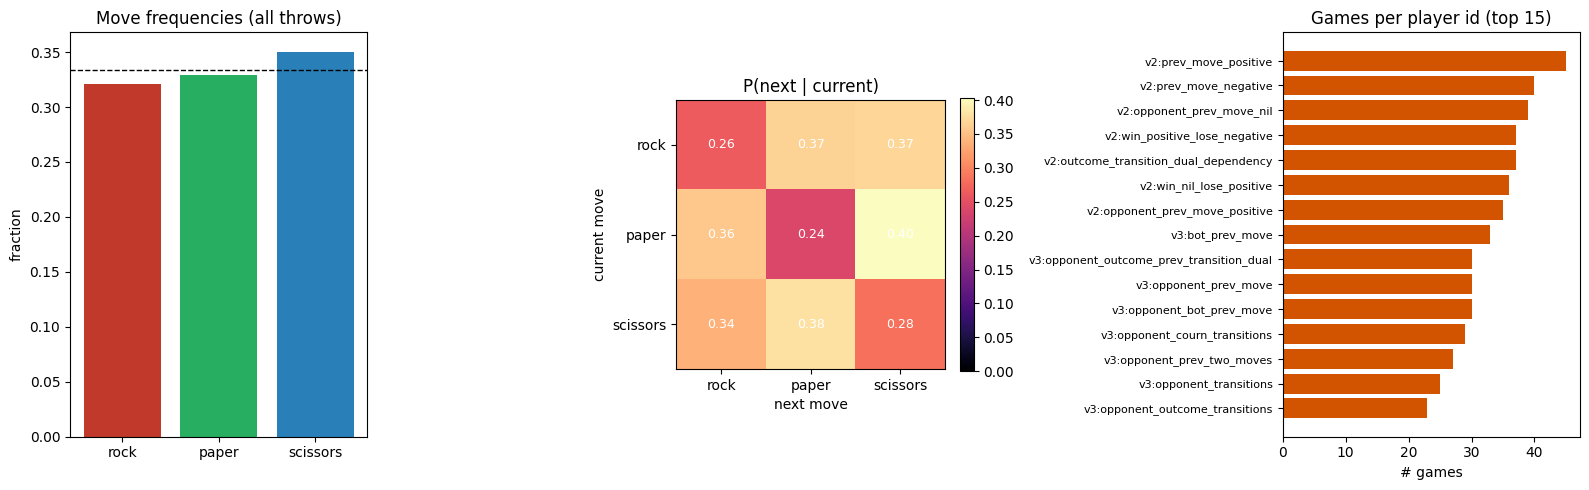

In [23]:
# plot some summary statistics of the data
all_moves    = np.concatenate([g.moves.ravel()    for g in games.values()])
all_outcomes = np.concatenate([g.outcomes.ravel() for g in games.values()])
rounds_per_game = np.array([len(g) for g in games.values()])
print(f"{len(games)} games, {len(all_moves)} throws, "
      f"{rounds_per_game.min()}-{rounds_per_game.max()} rounds/game")

# order-1 transition counts P(next move | current move), pooled over players & games
trans = np.zeros((3, 3))
for g in games.values():
    for p in range(2):
        for a, b in zip(g.moves[:-1, p], g.moves[1:, p]):
            trans[a, b] += 1
trans = trans / trans.sum(1, keepdims=True)

# summarize which player ids recur across many games; this should highlight the shared bot identities
top_players = games_per_player_series.head(15).sort_values()
top_player_labels = []
top_player_colors = []
for pid in top_players.index:
    if pid.startswith('bot:'):
        top_player_labels.append(pid[len('bot:'):])
        top_player_colors.append('#d35400')
    else:
        top_player_labels.append(pid.split(':', 1)[1][:8] + '...')
        top_player_colors.append('#95a5a6')

MCOLORS = ['#c0392b', '#27ae60', '#2980b9']        # rock / paper / scissors
fig, ax = plt.subplots(1, 3, figsize=(16, 5))

# (1) move frequencies -- look for the rock bias
ax[0].bar(NAMES, np.bincount(all_moves, minlength=3) / len(all_moves), color=MCOLORS)
ax[0].axhline(1/3, ls='--', c='k', lw=1, label='uniform (1/3)')
ax[0].set_title('Move frequencies (all throws)'); ax[0].set_ylabel('fraction');

# (2) order-1 transition matrix -- stickiness shows up on the diagonal
im = ax[1].imshow(trans, cmap='magma', vmin=0, vmax=trans.max())
ax[1].set_xticks(range(3)); ax[1].set_xticklabels(NAMES)
ax[1].set_yticks(range(3)); ax[1].set_yticklabels(NAMES)
ax[1].set_xlabel('next move'); ax[1].set_ylabel('current move')
ax[1].set_title('P(next | current)')
for r in range(3):
    for c in range(3):
        ax[1].text(c, r, f'{trans[r, c]:.2f}', ha='center', va='center',
                      color='white' if trans[r, c] < 0.5 else 'black', fontsize=9)
fig.colorbar(im, ax=ax[1], fraction=0.046)

# (3) shared bot ids now recur across games, so they should stand out in this histogram
ax[2].barh(range(len(top_players)), top_players.values, color=top_player_colors)
ax[2].set_yticks(range(len(top_players)))
ax[2].set_yticklabels(top_player_labels, fontsize=8)
ax[2].set_xlabel('# games')
ax[2].set_title('Games per player id (top 15)')

fig.tight_layout()


### Split games into train, holdout, and test

Since each player only plays in one game, take the start of every game for training, then split the end into a holdout chunk for early stopping and a final test chunk.


In [24]:
def split_games_temporally(games, context_length, holdout_fraction=holdout_fraction, test_fraction=test_fraction):
    train_data = {}
    holdout_data = {}
    test_data = {}
    short_train_only_games = []

    for game_id, g in games.items():
        n = len(g)
        n_targets = n - context_length

        # If a game is too short to support train + holdout + test, keep all of it in train.
        if n_targets < 3:
            train_data[game_id] = GameData.from_arrays(
                g.moves,
                g.outcomes,
                g.total,
                player_ids=g.player_ids,
            )
            short_train_only_games.append(game_id)
            continue

        # split the predict-able rounds (the rounds after the initial context window)
        # into train, holdout, and test targets.
        n_holdout = max(1, int(round(holdout_fraction * n_targets)))
        n_test = max(1, int(round(test_fraction * n_targets)))
        n_train = n_targets - n_holdout - n_test
        if n_train < 1:
            train_data[game_id] = GameData.from_arrays(
                g.moves,
                g.outcomes,
                g.total,
                player_ids=g.player_ids,
            )
            short_train_only_games.append(game_id)
            continue

        # convert the target-count split back into original round indices.
        holdout_round = context_length + n_train
        test_round = holdout_round + n_holdout

        # training chunk: rounds [0, ..., holdout_round-1]
        train_data[game_id] = GameData.from_arrays(
            g.moves[:holdout_round],
            g.outcomes[:holdout_round],
            g.total[:holdout_round],
            player_ids=g.player_ids,
        )

        # holdout chunk starts context_length rounds earlier so the first
        # holdout example has enough history to predict original round holdout_round.
        holdout_start = holdout_round - context_length
        holdout_data[game_id] = GameData.from_arrays(
            g.moves[holdout_start:test_round],
            g.outcomes[holdout_start:test_round],
            g.total[holdout_start:test_round],
            player_ids=g.player_ids,
        )

        # test chunk also starts context_length rounds earlier so the first
        # test example has enough history to predict original round test_round.
        test_start = test_round - context_length
        test_data[game_id] = GameData.from_arrays(
            g.moves[test_start:],
            g.outcomes[test_start:],
            g.total[test_start:],
            player_ids=g.player_ids,
        )

    return train_data, holdout_data, test_data, short_train_only_games

train_data, holdout_data, test_data, short_train_only_games = split_games_temporally(
    games,
    context_length=model_params['context_length'],
    holdout_fraction=holdout_fraction,
    test_fraction=test_fraction,
)

if short_train_only_games:
    print(f"Kept {len(short_train_only_games)} short games in train only.")
print(f"Total training moves: {sum(2*len(g) for g in train_data.values())}")
print(f"Total holdout moves: {sum(2*len(g) for g in holdout_data.values())}")
print(f"Total test moves: {sum(2*len(g) for g in test_data.values())}")


Kept 22 short games in train only.
Total training moves: 238720
Total holdout moves: 37186
Total test moves: 37186


### Helper functions

In [ ]:
# helper functions

def beats(move_in):  
    """Returns the move that beats move_in. If move_in is an array, returns an array of the same shape."""
    isscalar = np.isscalar(move_in)
    if isinstance(move_in, torch.Tensor):
        move_out = torch.zeros_like(move_in,dtype=torch.long)
    else:
        if not isinstance(move_in, np.ndarray):
            move_in = np.asarray(move_in, dtype=int)
        move_out = np.zeros_like(move_in, dtype=int)
    move_out[move_in == MOVE['rock']] = MOVE['paper']
    move_out[move_in == MOVE['paper']] = MOVE['scissors']
    move_out[move_in == MOVE['scissors']] = MOVE['rock']
        
    if isscalar:
        move_out = move_out.item()  # convert back to scalar if input was scalar
        
    return move_out

def winner(move_self, move_opp):
    """
    Returns self_outcome, opp_outcome, where each is 1 if that player wins, -1 if that player loses, 0 if tie. 
    move_self and move_opp are in [0,1,2] for rock/paper/scissors. If move_self and move_opp are arrays, returns arrays of the same shape.
    """
    self_isscalar = np.isscalar(move_self)
    opp_isscalar = np.isscalar(move_opp)
    if isinstance(move_self, torch.Tensor):
        self_outcome = torch.full_like(move_self, OUTCOME['win'])
    else:
        move_self = np.asarray(move_self, dtype=int)
        self_outcome = np.full_like(move_self, OUTCOME['win'])
    if isinstance(move_opp, torch.Tensor):
        opp_outcome = torch.full_like(move_opp, OUTCOME['loss'])
    else:
        move_opp = np.asarray(move_opp, dtype=int)
        opp_outcome = np.full_like(move_opp, OUTCOME['loss'])

    self_outcome[move_self == move_opp] = OUTCOME['tie']
    opp_outcome[move_self == move_opp]  = OUTCOME['tie']
    beats_self = beats(move_self)
    self_outcome[beats_self == move_opp] = OUTCOME['loss']
    opp_outcome[beats_self == move_opp]  = OUTCOME['win']

    if self_isscalar:
        self_outcome = self_outcome.item()  # convert back to scalar if input was scalar
    if opp_isscalar:
        opp_outcome = opp_outcome.item()  # convert back to scalar if input was scalar
    
    return self_outcome, opp_outcome

class RPSMixin:
    """Shared RPS-specific model utilities."""

    @staticmethod
    def _stack_features(x):
        """Convert a dataset batch dict into the self player id and per-round features."""
        if not isinstance(x, dict):
            raise TypeError('Expected a dict batch from RPSSequenceDataset')

        # Flatten the per-round inputs into one feature vector per timestep.
        feature_parts = [
            x['moves'].reshape(*x['moves'].shape[:-2], -1),
            x['outcomes'],
        ]
        if 'totals' in x:
            feature_parts.append(x['totals'])
        round_features = torch.cat(feature_parts, dim=-1)

        # Keep only the chosen self player's identity separate so the model can embed it.
        self_player_id = x['player_ids'][..., 0]
        return self_player_id, round_features

    @staticmethod
    def _pick(logits, sample):
        """Pick the next move from the model's output logits. 
        If sample=False, pick the argmax (greedy decoding). 
        If sample=True, sample from the softmax distribution (stochastic decoding).
        """
        
        # Greedy decoding picks the argmax; stochastic decoding samples from softmax probabilities.
        if not sample:
            return logits.argmax(-1)
        probs = F.softmax(logits, dim=-1)
        idx = torch.multinomial(probs.reshape(-1, probs.shape[-1]), 1).squeeze(-1)
        return idx.reshape(probs.shape[:-1])

    @torch.no_grad()
    def predict_probs(self, x):
        """Return class probabilities over [rock, paper, scissors]."""
        was_training = self.training
        self.eval()
        logits, _ = self(x)
        probs = F.softmax(logits, dim=-1)
        if was_training:
            self.train()
        return probs

    @torch.no_grad()
    def generate(self, dataset, x, n_new, sample=True):
        """
        Generate new moves for a given dataset and input.

        Args:
            dataset: The dataset to use for generating moves.
            x: The initial input state, shape (batch_size, context_length, d_input).
            n_new: The number of new moves to generate, scalar. 
            sample: Whether to use stochastic sampling or greedy decoding. Default True (stochastic).

        Returns:
            A tensor containing the generated moves, shape (batch_size, n_new, 2) where the last dimension is [move_self, move_opp].
        """
        
        was_training = self.training
        self.eval()
        moves = []
        for _ in range(n_new):
            # predict from the current [self, opp] view
            logits_self, _ = self(x)
            # and again after swapping players, so we can get a move for the opponent too.
            logits_opp,  _ = self(dataset.swap_players(x))
            move_self = self._pick(logits_self[..., -1, :], sample)
            move_opp  = self._pick(logits_opp[..., -1, :],  sample)

            # the newly generated round becomes the next input window.
            prediction = torch.stack([move_self, move_opp], dim=-1)
            moves.append(prediction)
            x = dataset.next_input(x, prediction)
        if was_training:
            self.train()
        return torch.stack(moves, dim=-2)


def batch_to_device(x, device):
    """Recursively move tensors in a nested batch to a device."""
    if torch.is_tensor(x):
        return x.to(device)
    if isinstance(x, dict):
        return {k: batch_to_device(v, device) for k, v in x.items()}
    return x


def print_nested_shapes(x, indent=0):
    """Pretty-print shapes for nested batch dicts, including metadata."""
    prefix = ' ' * indent
    if torch.is_tensor(x):
        print(f"{prefix}{tuple(x.shape)}")
    elif isinstance(x, dict):
        for k, v in x.items():
            if torch.is_tensor(v):
                print(f"{prefix}{k}: {tuple(v.shape)}")
            elif isinstance(v, dict):
                print(f"{prefix}{k}:")
                print_nested_shapes(v, indent + 2)
            else:
                print(f"{prefix}{k}: {type(v).__name__}")
    else:
        print(f"{prefix}{type(x).__name__}")


## 3. Define PyTorch Dataset

In [26]:
class RPSSequenceDataset(torch.utils.data.Dataset):
    """
    Next-round move prediction over two-player RPS games.

    The token is a ROUND (both players move simultaneously), not a single move. One example
    predicts a chosen player's move at round r from the previous `context_length` rounds
    (r-L .. r-1) -- round r itself is never an input.

    Features are made self-relative by reordering the player axis to [self, opp] (column 0 = the
    player whose move we predict).

    Returned inputs are dicts with:
      'moves'      : one-hot move,                      (L, 2, 3)
      'outcomes'   : outcome value as float (OUTCOME),  (L, 2)
      'totals'     : cumulative points after the round, (L, 2)   (included only if include_totals=True; optionally z-scored)
      'player_ids' : integer player id indices,         (2,)
    """
    def __init__(self, games, player_id_to_index, context_length, include_totals=False, **kwargs):
        self.context_length = context_length
        self.include_totals = include_totals
        if isinstance(games, dict):
            self.games = list(games.values())
            self.game_ids = list(games.keys())
        else:
            self.games = games
            self.game_ids = np.arange(len(games), dtype=int)

        self.player_id_to_index = player_id_to_index
        self.n_player_ids = len(player_id_to_index)
        self.index_to_player_id = {v: k for k, v in self.player_id_to_index.items()}

        # One supervised example for each (game, target round, target player).
        self.index = [
            (gamei, roundi, playeri)
            for gamei, g in enumerate(self.games)
            for roundi in range(context_length, len(g))
            for playeri in (0, 1)
        ]

        if 'zscore_params' in kwargs:
            self.zscore_params = {**kwargs['zscore_params']}
        else:
            self.zscore_params = {}
        if 'total_mean' not in self.zscore_params or 'total_std' not in self.zscore_params:
            all_tot = np.concatenate([g.total.ravel() for g in self.games]).astype(np.float32)
            self.zscore_params['total_mean'] = all_tot.mean()
            self.zscore_params['total_std'] = all_tot.std()
            if self.zscore_params['total_std'] == 0:
                self.zscore_params['total_std'] = 1.0

    def __len__(self):
        return len(self.index)

    def getitem(self, i, dozscore=False):
        """Get the i-th example as (x, y).
        Arguments:
            i: index of the example to retrieve
            dozscore: whether to z-score the 'totals' feature in x (default False, ignored if include_totals=False)
         Returns:
            x: dict of input tensors for the model, with keys:
                'moves': one-hot move,                      (L, 2, 3)
                'outcomes': outcome value as float (OUTCOME),  (L, 2)
                'totals': cumulative points after the round, (L, 2)   (included only if include_totals=True; optionally z-scored)
                'player_ids': integer player id indices,         (2,)
                'metadata': dict containing 'gamei', 'game_id', 'round', and 'player' for debugging/display purposes
            y: tensor of shape (L, 3) containing the one-hot next move of the chosen player for each round in the context window
         The input x contains the previous L rounds of moves, outcomes, and optionally totals for both players, with the player axis reordered 
         so column 0 is the chosen player ("self") and column 1 is the opponent. The target y is the next move of the chosen 
         player at each round in the context window, as a one-hot vector.
        """
        
        # which game, round, and player does this example correspond to?
        gamei, roundi, playeri = self.index[i]
        game = self.games[gamei]

        # input is the previous L rounds; target is the shifted sequence including round_i.
        past = slice(roundi - self.context_length, roundi)
        current = slice(roundi - self.context_length + 1, roundi + 1)

        # reorder columns so column 0 is always "self" and column 1 is "opponent".
        player_order = [playeri, 1 - playeri]
        moves = torch.from_numpy(game.moves[past][:, player_order].copy()).long()
        x = {
            'moves': F.one_hot(moves, num_classes=len(NAMES)).float(),                             # (L, 2, 3) 
            'outcomes': torch.from_numpy(game.outcomes[past][:, player_order].copy()).float(),     # (L, 2)
            'player_ids': torch.tensor([self.player_id_to_index[pid] for pid in game.player_ids[player_order]],dtype=torch.long), # (2,)

            # metadata for debugging/display
            'metadata': {
                'gamei': gamei,
                'game_id': self.game_ids[gamei],
                'round': roundi,
                'player': playeri,
            },
        }
        if self.include_totals:
            x['totals'] = torch.from_numpy(game.total[past][:, player_order].copy()).float()      # (L, 2)
        
        # target is the next move of the chosen player, as a one-hot vector.
        y = F.one_hot(torch.tensor(game.moves[current, playeri], dtype=torch.long),num_classes=len(NAMES)).float() # (L, 3)

        # zscore
        if dozscore:
            x = self.zscore({**x})

        return x, y

    def __getitem__(self, i):
        """
        Get the i-th example as (x, y), where x is a dict of tensors and y is the next move one-hot, dozscore=True
        Called when you do dataset[i]. See getitem for details and arguments.
        """
        
        return self.getitem(i, dozscore=True)

    def zscore(self, xdict):
        if 'totals' in xdict:
            xdict['totals'] = (xdict['totals'] - self.zscore_params['total_mean']) / self.zscore_params['total_std']
        return xdict

    def unzscore(self, xdict):
        if 'totals' in xdict:
            xdict['totals'] = xdict['totals'] * self.zscore_params['total_std'] + self.zscore_params['total_mean']
        return xdict

    def item_to_gamedata(self, x, waszscored=True):
        """
        Reconstruct a GameData object from a single example window (column 0 = self, column 1 = opp).
        Arguments:
            x: dict of tensors for a single example, with keys 'moves', 'outcomes', optionally 'totals', and 'player_ids'. 
            Each tensor has a leading dimension of the context length (L), and the player axis is [self, opp].
            waszscored: whether the 'totals' feature in x is currently z-scored (default True, set to False if x has already been unzscored).
        Returns:
            A GameData object reconstructed from the input tensors, with moves, outcomes, and totals for both players, and 
            player_ids mapped back to their original values. If totals are not present in x, they are reconstructed from the outcomes.
        """
        if waszscored:
            x = self.unzscore({**x})
        to_np = lambda t: t.detach().cpu().numpy()
        moves = to_np(x['moves'].argmax(-1)).astype(int)
        outcomes = to_np(x['outcomes'].round()).astype(int)
        if 'totals' in x:
            total = to_np(x['totals'].round()).astype(int)
        else:
            outcome_to_points = {
                OUTCOME['loss']: POINTS['loss'],
                OUTCOME['tie']: POINTS['tie'],
                OUTCOME['win']: POINTS['win'],
            }
            points = np.vectorize(outcome_to_points.get)(outcomes).astype(int)
            total = np.cumsum(points, axis=0)
        player_ids = np.array([self.index_to_player_id[i] for i in to_np(x['player_ids']).astype(int)])
        return GameData.from_arrays(moves, outcomes, total, player_ids=player_ids)

    def moves_to_gamedata(self, x_prompt, moves):
        """Reconstruct a GameData object from an initial prompt x and a generated sequence of moves, by 
        iteratively calling next_input.
        Arguments:
            x_prompt: dict of tensors for a single example, with keys 'moves', 'outcomes', optionally 'totals', and 'player_ids'.
            moves: tensor of generated moves to apply to the initial prompt. Each move is a pair of integers 
            [move_self, move_opp] corresponding to the predicted moves for the chosen player and opponent at each step. 
            The shape of moves should be (n_new, 2) where n_new is the number of generated rounds.
        Returns:
            A GameData object reconstructed from the initial prompt and the generated moves, with moves, outcomes
            and totals for both players, and player_ids mapped back to their original values. If totals were not provided in the prompt,
            they are reconstructed from the outcomes.
        """
        x = x_prompt
        gen = moves.to(x['moves'].device)
        for t in range(gen.shape[-2]):
            x = self.next_input(x, gen.select(-2, t), dodrop=False)
        return self.item_to_gamedata(x)

    def next_input(self, x, prediction, waszscored=True, dozscore=None, dodrop=True):
        """
        Create the next input sequence by appending the predicted move pair to the current input and 
        optionally dropping the oldest round, then z-scoring if needed. Used during generation to update the 
        model's input after each predicted round.
        Arguments:
            x: dict of tensors for the current input, with keys 'moves', 'outcomes', optionally 'totals', and 'player_ids'.
            prediction: tensor of predicted moves for the next round, with shape (..., 2) where the last dimension
            corresponds to [move_self, move_opp].
            waszscored: whether the input x is currently z-scored (default True, set to False if x has already been unzscored).
            dozscore: whether to z-score the output (default None, set to waszscored if None).
            dodrop: whether to drop the oldest round when appending the new round (default True).
        Returns:
            A dict of tensors representing the next input sequence, with keys 'moves', 'outcomes', optionally 'totals', and 'player_ids'.
            The new sequence includes the predicted move pair and the resulting outcomes, and totals if they are present in x.
            The 'totals' feature is z-scored if dozscore is True. The player axis remains in [self, opp] order.
        """
        
    
        if dozscore is None:
            dozscore = waszscored

        current = x if not waszscored else self.unzscore({**x})
        move_self, move_opp = prediction[..., 0].long(), prediction[..., 1].long()

        # compute the outcome of the new round based on the predicted moves
        self_outcome, opp_outcome = winner(move_self, move_opp)
        next_outcome = torch.stack([self_outcome, opp_outcome], dim=-1)

        # update the totals by adding the points from the new round to the previous totals if totals are present
        if 'totals' in current:
            next_points = torch.zeros_like(next_outcome, dtype=torch.float)
            for name in OUTCOME_NAMES:
                next_points[next_outcome == OUTCOME[name]] = POINTS[name]
            next_total = current['totals'][..., -1, :] + next_points
        next_move = F.one_hot(prediction.long(), num_classes=len(NAMES)).float()

        # slide the window forward by one round, or grow it if dodrop=False, window_len < context_length
        window_len = current['moves'].shape[-3]
        start = 1 if dodrop and window_len >= self.context_length else 0
        next_input = {
            'moves': torch.cat([current['moves'][..., start:, :, :], next_move.unsqueeze(-3)], dim=-3),
            'outcomes': torch.cat([current['outcomes'][..., start:, :], next_outcome.unsqueeze(-2).float()], dim=-2),
            'player_ids': current['player_ids'].clone(),
        }
        if 'totals' in current:
            next_input['totals'] = torch.cat([current['totals'][..., start:, :], next_total.unsqueeze(-2)], dim=-2)
        
        # metadata is te same
        if 'metadata' in current:
            next_input['metadata'] = {**current['metadata']}

        if dozscore:
            next_input = self.zscore(next_input)
        return next_input

    def swap_players(self, x):
        """Swap self<->opp in a dict window. [self, opp] -> [opp, self]."""
        if not isinstance(x, dict):
            raise TypeError('swap_players expects a feature dict')
        swapped = {
            'moves': x['moves'].flip(-2),
            'outcomes': x['outcomes'].flip(-1),
            'player_ids': x['player_ids'].flip(-1),
        }
        if 'totals' in x:
            swapped['totals'] = x['totals'].flip(-1)
        if 'metadata' in x:
            swapped['metadata'] = {**x['metadata'], 'player': 1 - x['metadata']['player']}
        return swapped

    def get_d_input(self):
        example_x, _ = self[0]
        d = example_x['moves'].shape[-2] * example_x['moves'].shape[-1] + example_x['outcomes'].shape[-1]
        if 'totals' in example_x:
            d += example_x['totals'].shape[-1]
        return d

    def get_d_output(self):
        _, example_y = self[0]
        return example_y.shape[-1]


# create the train, holdout, and test datasets and dataloaders
train_dataset = RPSSequenceDataset(
    train_data,
    player_id_to_index=player_id_to_index,
    context_length=model_params['context_length'],
    include_totals=model_params['include_totals'],
)
holdout_dataset = RPSSequenceDataset(
    holdout_data,
    player_id_to_index=player_id_to_index,
    context_length=model_params['context_length'],
    include_totals=model_params['include_totals'],
    zscore_params=train_dataset.zscore_params,
)
test_dataset = RPSSequenceDataset(
    test_data,
    player_id_to_index=player_id_to_index,
    context_length=model_params['context_length'],
    include_totals=model_params['include_totals'],
    zscore_params=train_dataset.zscore_params,
)

model_params['n_player_ids'] = train_dataset.n_player_ids
model_params['d_input'] = train_dataset.get_d_input()
model_params['d_output'] = train_dataset.get_d_output()

train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=model_params['batch_size'], shuffle=True)
holdout_dataloader = torch.utils.data.DataLoader(holdout_dataset, batch_size=model_params['batch_size'], shuffle=False)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=model_params['batch_size'], shuffle=False)

# test out the datasets/dataloaders
example_x, example_y = train_dataset[0]
print('Input shapes:')
for k, v in example_x.items():
    if k != 'metadata':
        print(f"  {k}: {tuple(v.shape)}")
print(f"Output shape: {tuple(example_y.shape)}")

example_x, example_y = train_dataset.getitem(0, dozscore=False)
print('\nInput (no zscore):')
for k, v in example_x.items():
    if k == 'metadata':
        print(f"{k}: {v}")
    else:
        print(f"{k}: shape: {tuple(v.shape)}\n{v}")
print(f"Output (no zscore): shape: {tuple(example_y.shape)}\n{example_y}")

batch_x, batch_y = next(iter(train_dataloader))
print('\nBatch input shapes:')
print_nested_shapes(batch_x, indent=2)
print(f"Batch output shape: {tuple(batch_y.shape)}")


Input shapes:
  moves: (8, 2, 3)
  outcomes: (8, 2)
  player_ids: (2,)
  totals: (8, 2)
Output shape: (8, 3)

Input (no zscore):
moves: shape: (8, 2, 3)
tensor([[[0., 0., 1.],
         [0., 0., 1.]],

        [[0., 1., 0.],
         [1., 0., 0.]],

        [[0., 0., 1.],
         [1., 0., 0.]],

        [[0., 0., 1.],
         [0., 0., 1.]],

        [[0., 0., 1.],
         [0., 1., 0.]],

        [[0., 0., 1.],
         [0., 0., 1.]],

        [[0., 1., 0.],
         [1., 0., 0.]],

        [[0., 1., 0.],
         [0., 1., 0.]]])
outcomes: shape: (8, 2)
tensor([[ 0.,  0.],
        [ 1., -1.],
        [-1.,  1.],
        [ 0.,  0.],
        [ 1., -1.],
        [ 0.,  0.],
        [ 1., -1.],
        [ 0.,  0.]])
player_ids: shape: (2,)
tensor([17, 24])
metadata: {'gamei': 0, 'game_id': 'v1:0283f6be-802c-4f51-bd49-7ddbc6d9dc84', 'round': 8, 'player': 0}
totals: shape: (8, 2)
tensor([[ 0.,  0.],
        [ 3., -1.],
        [ 2.,  2.],
        [ 2.,  2.],
        [ 5.,  1.],
        [ 5.,

In [9]:
# # sanity check: advancing the round-L window by the TRUE round-L moves should reproduce the round-(L+1) window
# game0 = train_dataset.games[0]

# for round in range(train_dataset.context_length, len(game0)-1):

#     # find the two examples for game 0, player 0 (self), predicting round round and round round+1
#     i0 = train_dataset.index.index((0, round,   0))   # window over rounds [0,   round-1], predicts round round
#     i1 = train_dataset.index.index((0, round+1, 0))   # window over rounds [1,   round  ], predicts round round+1
#     x0, _ = train_dataset[i0]                      # collated, z-scored
#     x1, _ = train_dataset[i1]

#     # true moves at round round, in [self, opp] = [player0, player1] order (self = player 0)
#     prediction = torch.tensor(game0.moves[round])      # (2,)
#     x0_next = train_dataset.next_input(x0, prediction)   # advance by the real round

#     print(f"Sanity check for game 0, player 0, round {round} -> {round+1}:")
#     print('shapes :', tuple(x0_next.shape), tuple(x1.shape))
#     print('allclose:', torch.allclose(x0_next, x1, atol=1e-5))
#     print('max |diff|:', (x0_next - x1).abs().max().item())

#     # per-field breakdown so a mismatch tells you which feature is wrong
#     dn, dt = train_dataset.uncollate(x0_next), train_dataset.uncollate(x1)
#     for k in dn:
#         print(f'  {k:8s} max |diff| = {(dn[k] - dt[k]).abs().max().item():.3g}')


## 4. Classification with PyTorch

### Logistic Regression and Cross-Entropy Loss

Logistic regression is a **linear model**. In our case, that means the model takes the input features for a round and computes three output scores, one for each possible next move:

$$
\text{logits} = W x + b
$$

where:
- $x$ is the input feature vector
- $W$ is a learned weight matrix
- $b$ is a learned bias vector

The logits are then converted into probabilities using the **softmax** function:

$$
p_i \propto e^{z_i}
$$

The target is the move that actually happened, encoded as a one-hot vector. Cross-entropy loss measures how much probability the model assigned to that true move:

$$
\mathrm{loss} = -\log p(\text{true move})
$$

### Define logistic regression model in PyTorch

In [9]:
class LogisticRegressionModel(RPSMixin, nn.Module):
    """Per-round multinomial logistic regression with a learned player-id embedding."""

    def __init__(self, p):
        """Initialize the model with parameters p, which should include:
            p['n_player_ids']: the number of unique player ids (for the embedding layer)
            p['d_output']: the dimensionality of the output (number of move classes, e.g. 3 for rock/paper/scissors)
        """
        super().__init__()
        
        # player embedding: goes from player id index -> d_output-dim vector
        # equivalent to making a one-hot encoder and multiplying by a weight matrix
        self.player_emb = nn.Embedding(p['n_player_ids'], p['d_output'])
        
        # the round features produce one set of logits...
        self.linear = nn.Linear(p['d_input'], p['d_output'])
        # ...and the self-player embedding provides an additive logits offset directly.

    def forward(self, x, targets=None):
        """
        Forward pass of the model. Takes a batch of input dicts x and optional targets, and returns (logits, loss).
        Arguments:
            x: dict of input tensors, with keys: 
            'moves': one-hot move,                         (B, L, 2, d_output)
            'outcomes': outcome value as float (OUTCOME),  (B, L, 2)
            'totals': cumulative points after the round,   (B, L, 2) (present only if the dataset includes totals)
            'player_ids': integer player id indices [self, opp], (B, 2)
            targets: tensor of shape (B, L, d_output) containing the one-hot next move of the chosen player for each
            round in the context window (optional, used for computing loss during training)
        """
        
        # Single examples come in as (T, ...); training batches come in as (B, T, ...).
        squeezed = x['moves'].dim() == 3
        if squeezed:
            x = {k: v.unsqueeze(0) if torch.is_tensor(v) else v for k, v in x.items()}
        
        # Turn each round into one feature vector, then add a learned logits bias for the chosen
        # "self" player only (not the opponent identity).
        self_player_id, round_features = self._stack_features(x)
        B, T, _ = round_features.shape
        
        # pass round features through a linear layer to get base logits
        round_logits = self.linear(round_features)
        
        # pass self player id through the embedding layer to get a player logits
        player_logits = self.player_emb(self_player_id).unsqueeze(1).expand(-1, T, -1)
        logits = round_logits + player_logits

        loss = None
        # if targets are provided, compute the cross-entropy loss between the logits and the targets
        if targets is not None:

            # unsqueeze if targets are for a single example
            if targets.dim() == 2:
                targets = targets.unsqueeze(0)

            # cross entrropy loss
            C = logits.shape[-1]
            loss = F.cross_entropy(logits.reshape(-1, C), targets.reshape(-1, C))

        if squeezed:
            logits = logits.squeeze(0)

        return logits, loss

model = LogisticRegressionModel(model_params).to(device)

# test out the model on a sample batch
xb, yb = next(iter(train_dataloader))
print('Batch input shapes:')
print_nested_shapes(xb, indent=2)
print(f"Batch output shape: {yb.shape}")
with torch.no_grad():
    logits, loss = model(batch_to_device(xb, device), yb.to(device))
print(f"Logits shape: {logits.shape}, Loss: {loss.item():.4f}")

acc = (logits.argmax(-1).cpu() == yb.argmax(-1)).float().mean()
print(f"next-move accuracy for sample batch: {acc:.3f}   (chance = {1/len(NAMES):.3f})")


Batch input shapes:
  moves: (64, 8, 2, 3)
  outcomes: (64, 8, 2)
  player_ids: (64, 2)
  metadata:
    gamei: (64,)
    game_id: list
    round: (64,)
    player: (64,)
Batch output shape: torch.Size([64, 8, 3])
Logits shape: torch.Size([64, 8, 3]), Loss: 1.2571
next-move accuracy for sample batch: 0.393   (chance = 0.333)


#### Train logistic regression

  0%|          | 0/7190 [00:00<?, ?it/s]

Initial loss before training: train: 1.4372, holdout: 1.5160
Epoch 1/2: train loss: 1.0685, train acc: 0.4065, holdout loss: 1.0682, holdout acc: 0.4097
Epoch 2/2: train loss: 1.0595, train acc: 0.4093, holdout loss: 1.0627, holdout acc: 0.4107
Best holdout checkpoint: epoch 2
train loss: 1.0595, train accuracy: 0.4093
holdout loss: 1.0627, holdout accuracy: 0.4107
test loss: 1.0610, test accuracy: 0.4118


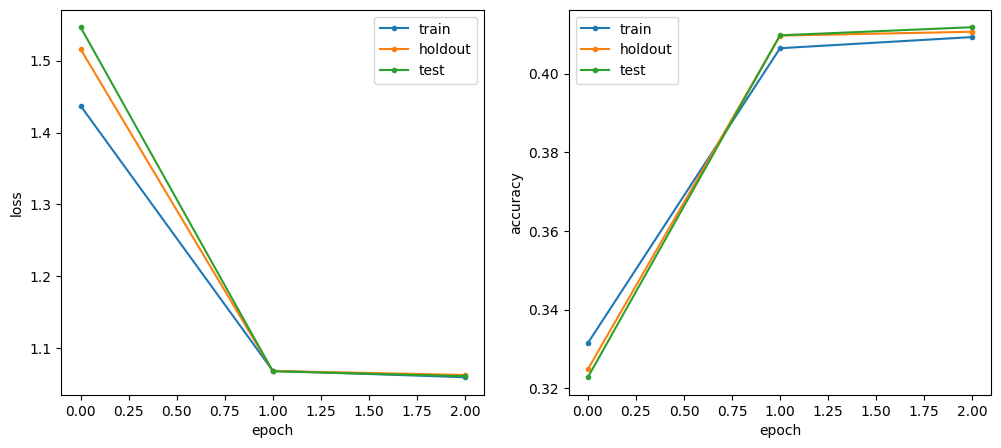

In [ ]:
# create the model
model = LogisticRegressionModel(model_params).to(device)

# let's just train for a few epochs to see if the model can learn something nontrivial, even with this simple architecture
n_epochs_logistic_regression = 2

def compute_loss_and_accuracy(dataloader, model, device):
    """Compute the average loss and accuracy of the model on a dataloader without updating parameters.
    Iterates through all batches and averages loss over batches.
    Arguments:
        dataloader: DataLoader providing batches of input data and targets
        model: the model to evaluate
        device: the device to run the computation on
    Returns:
        loss: the average loss of the model on the dataloader
        accuracy: the fraction of examples for which the model's highest logit matches the target move
    """
    total_loss = 0.
    total_correct = 0
    total_count = 0
    was_training = model.training
    model.eval()
    with torch.no_grad():
        for xb, yb in dataloader:
            xb = batch_to_device(xb, device)
            yb = yb.to(device)
            logits, loss = model(xb, yb)
            total_loss += loss.item()

            pred = logits.argmax(dim=-1)
            target = yb.argmax(dim=-1)
            total_correct += (pred == target).sum().item()
            total_count += target.numel()
    if was_training:
        model.train()
    return total_loss / len(dataloader), total_correct / total_count


# keep track of train, holdout, and test loss and accuracy over epochs for plotting
all_loss = {}
all_accuracy = {}
for k, dataloader in zip(['train', 'holdout', 'test'], [train_dataloader, holdout_dataloader, test_dataloader]):
    all_loss[k], all_accuracy[k] = compute_loss_and_accuracy(dataloader, model, device)
    all_loss[k] = [all_loss[k]]  # convert to list so we can append epoch losses
    all_accuracy[k] = [all_accuracy[k]] 

# initialize the optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=model_params['learning_rate'],
                              weight_decay=model_params['weight_decay'])

# initialize the learning rate scheduler if specified
if model_params['scheduler_type'] == 'OneCycleLR':
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        **lr_scheduler_params,
        optimizer=optimizer,
        total_steps=n_epochs_logistic_regression * len(train_dataloader),
    )
elif model_params['scheduler_type'] == 'CosineAnnealingLR':
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(**lr_scheduler_params, optimizer=optimizer)
elif model_params['scheduler_type'] is None:
    scheduler = None
else:
    raise ValueError(f"Unsupported scheduler type: {model_params['scheduler_type']}")

# main training loop
best_holdout_loss = all_loss['holdout'][0]
best_epoch = 0
epochs_without_improvement = 0
best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
patience = model_params['early_stopping_patience']
total = n_epochs_logistic_regression * len(train_dataloader)
pbar = tqdm(total=total)
print(f"Before training: train loss: {all_loss['train'][-1]:.4f}, train acc: {all_accuracy['train'][-1]:.4f}, holdout loss: {all_loss['holdout'][-1]:.4f}, holdout acc: {all_accuracy['holdout'][-1]:.4f}")

# iterate over epochs
for epoch in range(n_epochs_logistic_regression):
    # iterate over batches
    for xb, yb in train_dataloader:
        xb = batch_to_device(xb, device)
        yb = yb.to(device)

        logits, loss = model(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        if scheduler is not None:
            scheduler.step()
        lr = optimizer.param_groups[0]['lr']
        pbar.update(1)
        pbar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{lr:.2e}")

    # compute the loss on the train and holdout sets at the end of the epoch for monitoring
    for k, dataloader in zip(['train', 'holdout', 'test'], [train_dataloader, holdout_dataloader, test_dataloader]):
        loss_curr, acc_curr = compute_loss_and_accuracy(dataloader, model, device)
        all_loss[k].append(loss_curr)
        all_accuracy[k].append(acc_curr)
    print(f"Epoch {epoch+1}/{n_epochs_logistic_regression}: train loss: {all_loss['train'][-1]:.4f}, train acc: {all_accuracy['train'][-1]:.4f}, holdout loss: {all_loss['holdout'][-1]:.4f}, holdout acc: {all_accuracy['holdout'][-1]:.4f}")

    # keep the best holdout checkpoint and stop once the holdout loss stops improving
    if all_loss['holdout'][-1] < best_holdout_loss:
        best_holdout_loss = all_loss['holdout'][-1]
        best_epoch = epoch + 1
        epochs_without_improvement = 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping after epoch {epoch+1}: no holdout improvement for {patience} epochs.")
            break

pbar.close()
model.load_state_dict(best_state)

print(f"Best holdout checkpoint: epoch {best_epoch}")
for k in ['train', 'holdout', 'test']:
    print(f"{k} loss: {all_loss[k][best_epoch]:.4f}, {k} accuracy: {all_accuracy[k][best_epoch]:.4f}")

# plot the train and holdout loss curves over epochs
fig, ax = plt.subplots(1,2, figsize=(12, 5))
for k in ['train', 'holdout', 'test']:
    ax[0].plot(all_loss[k], '.-', label=k)
    ax[1].plot(all_accuracy[k], '.-', label=k)
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('loss')
ax[0].legend()
ax[1].set_xlabel('epoch')
ax[1].set_ylabel('accuracy')
ax[1].legend()

In [37]:
# generate some moves
x0, y0 = holdout_dataset[0]
x0_device = batch_to_device(x0, device)
moves = model.generate(train_dataset, x0_device, n_new=model_params['context_length'], sample=True)
full_game = holdout_dataset.moves_to_gamedata(x0_device, moves)
moves = moves.cpu()

prompt_game = holdout_dataset.item_to_gamedata(x0)
print('Prompt:')
display(prompt_game.show())
print('Generated continuation:')
display(full_game.show(start=len(prompt_game)))


Prompt:


round,0,1,2,3,4,5,6,7
player 0,✂️,📄,✂️,🪨,🪨,🪨,🪨,📄
player 1,✂️,✂️,🪨,📄,📄,✂️,🪨,📄
winner,0,1,1,1,1,-1,0,0
total 0,96,95,94,93,92,95,95,95
total 1,200,203,206,209,212,211,211,211


Generated continuation:


round,8,9,10,11,12,13,14,15
player 0,📄,✂️,✂️,📄,🪨,✂️,🪨,🪨
player 1,✂️,✂️,📄,📄,🪨,✂️,🪨,📄
winner,1,0,-1,0,0,0,0,1
total 0,94,94,97,97,97,97,97,96
total 1,214,214,213,213,213,213,213,216


## 5. Intro to transformers and attention

From Karpathy's Let's build GPT from scratch, in code, spelled out
https://www.youtube.com/watch?v=kCc8FmEb1nY
(more lessons from Karpathy here https://karpathy.ai/zero-to-hero.html)

In [13]:
# toy example illustrating how matrix multiplication can be used for a "weighted aggregation"
B,T,C = 4,8,2 # batch size, sequence length, feature dimension
x = torch.randn(B,T,C)

# We want x[b,t] = mean_{i<=t} x[b,i]

# version 1: slow loop
xbow1 = torch.zeros((B,T,C))
for b in range(B):
    for t in range(T):
        xprev = x[b,:t+1] # (t,C)
        xbow1[b,t] = torch.mean(xprev, 0)
        
print('x[0]:\n', x[0])
print('xbow1[0]:\n', xbow1[0])

# version 2: using matrix multiply for a weighted aggregation
tril = torch.tril(torch.ones(T, T))
wei = torch.zeros((T,T)) # set some weights, for now all the same
wei = wei.masked_fill(tril == 0, float('-inf')) # mask out the upper triangle so we only attend to current and past positions
print('wei (pre-softmax):\n', wei)
wei = F.softmax(wei, dim=-1) # normalize 
print('wei (after softmax):\n', wei)
xbow2 = wei @ x
assert torch.allclose(xbow1, xbow2), "matrix multiply version should match the loop version"


x[0]:
 tensor([[-2.0243,  1.4325],
        [ 0.3198, -0.8291],
        [-0.2657, -0.3154],
        [ 0.8577, -0.2628],
        [-0.7575,  0.1124],
        [-0.3988,  1.1847],
        [ 0.0676,  1.0904],
        [-0.2474,  0.7635]])
xbow1[0]:
 tensor([[-2.0243,  1.4325],
        [-0.8522,  0.3017],
        [-0.6567,  0.0960],
        [-0.2781,  0.0063],
        [-0.3740,  0.0275],
        [-0.3781,  0.2204],
        [-0.3145,  0.3447],
        [-0.3061,  0.3970]])
wei (pre-softmax):
 tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0., 0., 0., 0.]])
wei (after softmax):
 tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000

Illustrations from https://jalammar.github.io/illustrated-transformer/

The query, key, and value matrices:

![query, key, value](https://jalammar.github.io/images/t/self-attention-matrix-calculation.png)

Attention weights:

![self-attention](https://jalammar.github.io/images/t/self-attention-matrix-calculation-2.png)


Text(0, 0.5, 'time')

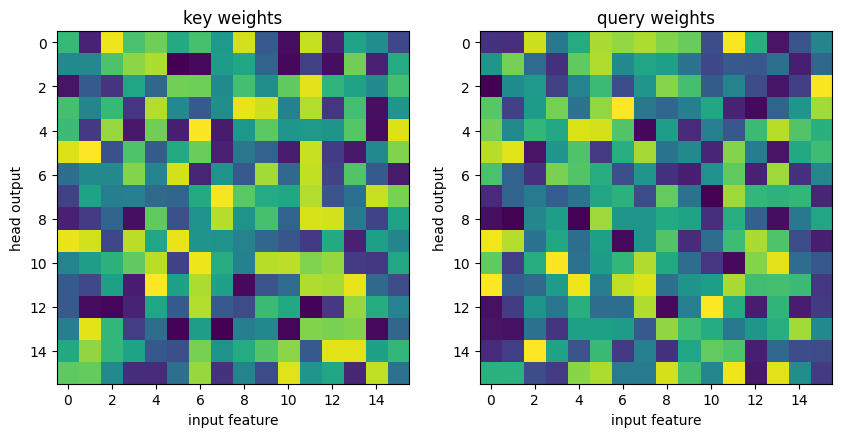

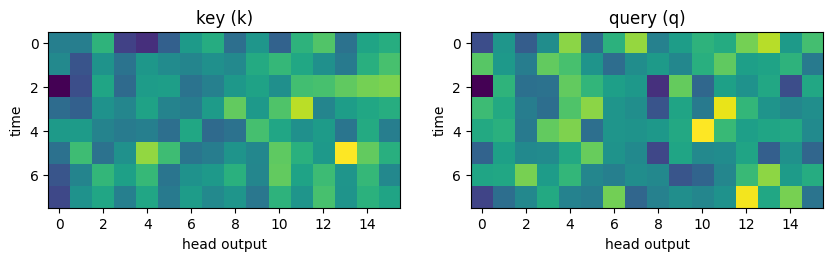

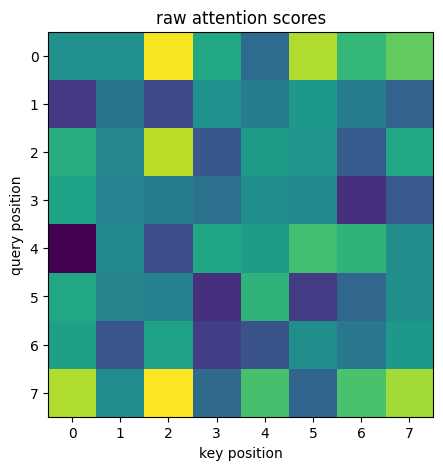

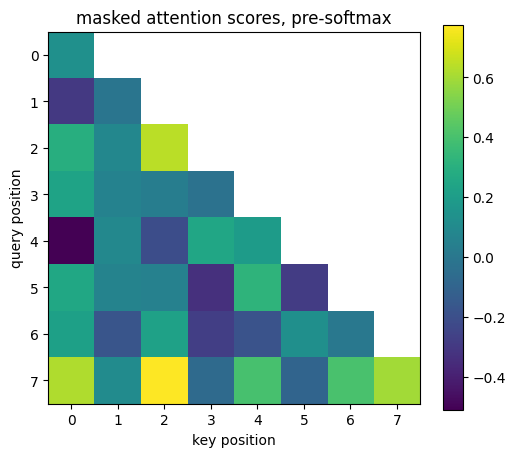

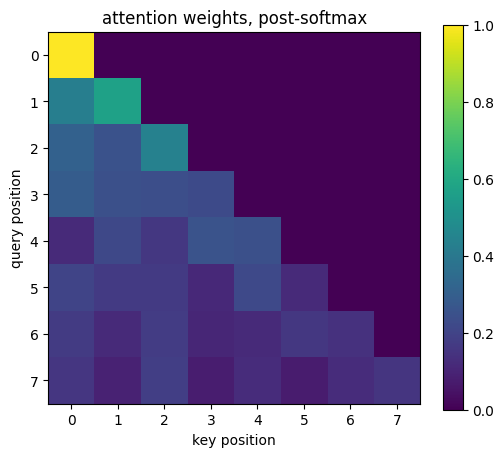

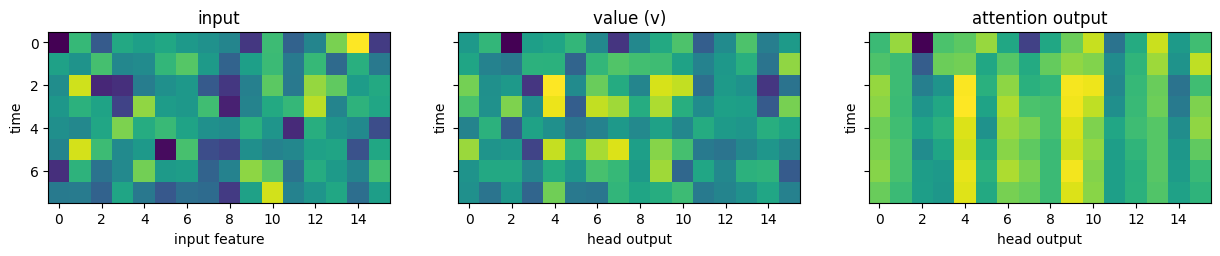

In [14]:
# another toy example with weights that depend on self attention
B,T,C = 4,8,16 # batch size, sequence length, feature dimension
x = torch.randn(B,T,C)

d_head = C

# randomly initialized linear maps for query and key, defines the space in which we compute similarity for attention
key = nn.Linear(C, d_head, bias=False)
query = nn.Linear(C, d_head, bias=False)
fig,ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].imshow(key.weight.detach().cpu().numpy())
ax[0].set_title('key weights')
ax[0].set_xlabel('input feature'); ax[0].set_ylabel('head output')
ax[1].imshow(query.weight.detach().cpu().numpy())
ax[1].set_title('query weights')
ax[1].set_xlabel('input feature'); ax[1].set_ylabel('head output')

# multiply
k = key(x)   # (B,T,d_head)
q = query(x) # (B,T,d_head)

fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].imshow(k[0].detach().cpu().numpy())
ax[0].set_title('key (k)')
ax[0].set_xlabel('head output'); ax[0].set_ylabel('time')
ax[1].imshow(q[0].detach().cpu().numpy())
ax[1].set_title('query (q)')
ax[1].set_xlabel('head output'); ax[1].set_ylabel('time')

# compute dot product between query and key at each position, to get the raw attention scores
# (B, T, d_head) @ (B, d_head, T) -> (B, T, T)
# dim 1 corresponds to query position and dim 2 corresponds to key position
wei = q @ k.transpose(-2, -1) * d_head**-0.5 # (B,T,T) raw attention scores for each query position attending to each key position

fig, ax = plt.subplots(figsize=(6,5))
ax.imshow(wei[0].detach().cpu().numpy())
ax.set_title('raw attention scores')
ax.set_xlabel('key position'); ax.set_ylabel('query position')

# mask out the upper triangle so we only attend to current and past positions
tril = torch.tril(torch.ones(T, T))
wei = wei.masked_fill(tril == 0, float('-inf'))
fig, ax = plt.subplots(figsize=(6,5))
him = ax.imshow(wei[0].detach().cpu().numpy())
# colorbar
fig.colorbar(him, ax=ax)
ax.set_title('masked attention scores, pre-softmax');
ax.set_xlabel('key position'); ax.set_ylabel('query position')

# normalize the attention scores to get the attention weights
wei = F.softmax(wei, dim=-1)
fig, ax = plt.subplots(figsize=(6,5))
him = ax.imshow(wei[0].detach().cpu().numpy())
# colorbar
fig.colorbar(him, ax=ax)
ax.set_title('attention weights, post-softmax')
ax.set_xlabel('key position'); ax.set_ylabel('query position')

# apply the weighting to values instead of x, to get the full attention mechanism
value = nn.Linear(C, d_head, bias=False)
v = value(x) # (B,T,d_head)
out = wei @ v # (B,T,T) @ (B,T,d_head) -> (B,T,d_head) weighted aggregation of values at each position according to attention weights
ncols = [x.shape[-1], v.shape[-1], out.shape[-1]]   # e.g. [D, d_head, d_head]
fig, ax = plt.subplots(1, 3, figsize=(15,5), sharey=True,
                       gridspec_kw={'width_ratios': ncols})
ax[0].imshow(x[0].detach().cpu().numpy())
ax[0].set_title('input')
ax[0].set_xlabel('input feature'); ax[0].set_ylabel('time')
ax[1].imshow(v[0].detach().cpu().numpy())
ax[1].set_title('value (v)')
ax[1].set_xlabel('head output'); ax[1].set_ylabel('time')
ax[2].imshow(out[0].detach().cpu().numpy())
ax[2].set_title('attention output')
ax[2].set_xlabel('head output'); ax[2].set_ylabel('time')

Notes:

- Attention is a **communication mechanism**. Can be seen as nodes in a directed graph looking at each other and aggregating information with a weighted sum from all nodes that point to them, with data-dependent weights.
- There is no notion of space. Attention simply acts over a set of vectors. This is why we need to positionally encode tokens.
- Each example across batch dimension is of course processed completely independently and never "talk" to each other
- **Self-attention** just means that the keys and values are produced from the same source as queries.
- "Scaled" attention additional divides wei by 1/sqrt(head_size). This makes it so when input Q,K are unit variance, wei will be unit variance too and Softmax will stay diffuse and not saturate too much. Illustration below

### Define an attention head module

Text(0, 0.5, 'time')

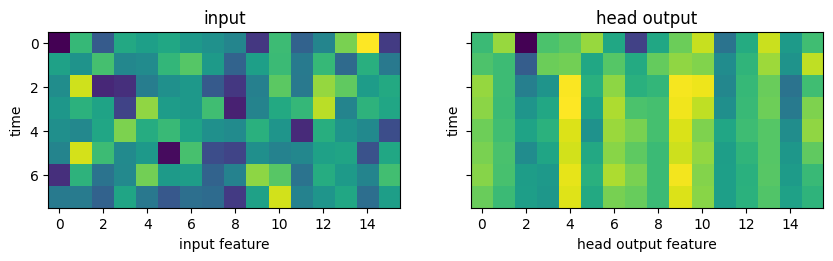

In [15]:
class Head(nn.Module):
    """one head of self-attention"""

    def __init__(self, d_head, d_embed, context_length, dropout=0.0):
        super().__init__()
        self.key = nn.Linear(d_embed, d_head, bias=False)
        self.query = nn.Linear(d_embed, d_head, bias=False)
        self.value = nn.Linear(d_embed, d_head, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(context_length, context_length)))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B,T,C = x.shape
        k = self.key(x)   # (B,T,C)
        q = self.query(x) # (B,T,C)
        # compute attention scores ("affinities")
        wei = q @ k.transpose(-2,-1) * C**-0.5 # (B, T, C) @ (B, C, T) -> (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B, T, T)
        wei = F.softmax(wei, dim=-1) # (B, T, T)
        wei = self.dropout(wei)
        # perform the weighted aggregation of the values
        v = self.value(x) # (B,T,C)
        out = wei @ v # (B, T, T) @ (B, T, C) -> (B, T, C)
        return out
    
head = Head(d_head=d_head,d_embed=C,context_length=T)

# set the weights to the weights we already defined for the toy example, so we can verify the head reproduces the same output
with torch.no_grad():
    head.key.weight.copy_(key.weight)
    head.query.weight.copy_(query.weight)
    head.value.weight.copy_(value.weight)

out = head(x)

ncols = [x.shape[-1], out.shape[-1]] 
fig, ax = plt.subplots(1, 2, figsize=(10,5), sharey=True, gridspec_kw={'width_ratios': ncols})
ax[0].imshow(x[0].detach().cpu().numpy())
ax[0].set_title('input')
ax[0].set_xlabel('input feature'); ax[0].set_ylabel('time')
ax[1].imshow(out[0].detach().cpu().numpy())
ax[1].set_title('head output')
ax[1].set_xlabel('head output feature'); ax[1].set_ylabel('time')

### Equivalent PyTorch code

Text(0, 0.5, 'time')

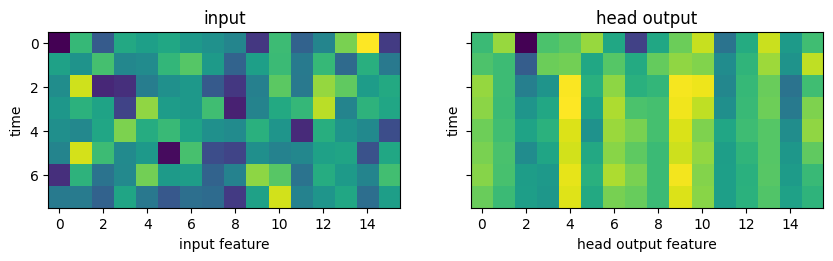

In [16]:
# compare to torch's built-in multi-head attention for verification
mha = nn.MultiheadAttention(embed_dim=C, num_heads=1, bias=False, batch_first=True)

# copy the toy weights so the module reproduces the same output as the hand-written head
with torch.no_grad():
    mha.in_proj_weight.copy_(torch.cat([query.weight, key.weight, value.weight], dim=0))  # rows = [q; k; v]
    mha.out_proj.weight.copy_(torch.eye(C))   # identity -> no output projection (match the bare head)

causal = torch.triu(torch.ones(T, T, dtype=torch.bool), diagonal=1)   # True = blocked
out, attn = mha(x, x, x, attn_mask=causal, need_weights=True)         # out: (B,T,C), attn: (B,T,T), inputs are value, key, query, all = x

ncols = [x.shape[-1], out.shape[-1]]
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True, gridspec_kw={'width_ratios': ncols})
ax[0].imshow(x[0].detach().cpu().numpy())
ax[0].set_title('input'); ax[0].set_xlabel('input feature'); ax[0].set_ylabel('time')
ax[1].imshow(out[0].detach().cpu().numpy())
ax[1].set_title('head output'); ax[1].set_xlabel('head output feature'); ax[1].set_ylabel('time')

### Attention is position invariant

Text(0, 0.5, 'time')

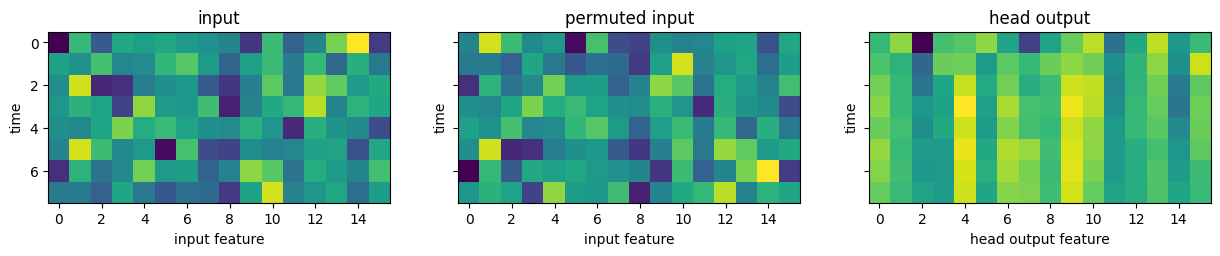

In [17]:
# randomly permute x along the time dimension
perm = torch.randperm(T)
x_perm = x[:, perm, :]

# copy the toy weights so the module reproduces the same output as the hand-written head
with torch.no_grad():
    mha.in_proj_weight.copy_(torch.cat([query.weight, key.weight, value.weight], dim=0))  # rows = [q; k; v]
    mha.out_proj.weight.copy_(torch.eye(C))   # identity -> no output projection (match the bare head)

causal = torch.triu(torch.ones(T, T, dtype=torch.bool), diagonal=1)   # True = blocked
# out: (B,T,C), attn: (B,T,T), inputs are value = x_perm, key = x_perm, query = x
out, attn = mha(x_perm, x_perm, x, attn_mask=causal, need_weights=True)         

ncols = [x.shape[-1], x_perm.shape[-1], out.shape[-1]]
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True, gridspec_kw={'width_ratios': ncols})
ax[0].imshow(x[0].detach().cpu().numpy())
ax[0].set_title('input'); ax[0].set_xlabel('input feature'); ax[0].set_ylabel('time')
ax[1].imshow(x_perm[0].detach().cpu().numpy())
ax[1].set_title('permuted input'); ax[1].set_xlabel('input feature'); ax[1].set_ylabel('time')
ax[2].imshow(out[0].detach().cpu().numpy())
ax[2].set_title('head output'); ax[2].set_xlabel('head output feature'); ax[2].set_ylabel('time')

### Other stuff in a transformer layer

So far we have **one attention head**. A real transformer wraps that in a few more pieces.

**Multi-headed attention**

![Multi-headed attention](https://jalammar.github.io/images/t/transformer_multi-headed_self-attention-recap.png)

From [The illustrated transformer](https://jalammar.github.io/illustrated-transformer/)

- Train **many** attention heads in parallel, each with its own Q/K/V projections.
- With `n_head` heads, each head works in `d_embed / n_head` dimensions. 
- Each head can specialize (e.g. "what did I play last round?" vs "did I just win?").
- **Concatenate** their outputs, then combine with one linear layer.

```
for i in range(n_head):
    head[i] = Head(x, Wq[i], Wk[i], Wv[i])
```
where each weight matrix `Wq[i]`, `Wk[i]`, `Wv[i]` are shape `(d_embed, d_embed / n_head)`

The heads are concatenated and mixed by a linear layer
```
xa = concat([Head(x,Wq[i],Wk[i],Wv[i]) for i in range(n_head)]) @ Wo
```

**Feed-forward network (MLP)**

![MLP and residual connections](https://miro.medium.com/v2/resize:fit:720/format:webp/1*8lAtTYcAgw5nBII5kdpFBg.png)

From [Mastering LLama — Understanding Residual Connection](https://medium.com/@hugmanskj/mastering-llama-understanding-residual-connection-447b5e85c355)

- After attention *mixes information across time*, a per-position MLP *computes on it*:
```
xa = MLP(x + xa)
```
where the MLP consists of `Linear(d_embed → 4·d_embed) → ReLU → Linear(4·d_embed → d_embed)`.
- This is applied independently at every position; the `4×` hidden width is the convention.
- This is where the nonlinear "thinking" happens — attention alone is mostly linear mixing.

**Residual connections**

- Each sublayer adds its input back: `x = x + xa`.
- Gives gradients a clean path through many layers, so deep stacks train.

**Layer normalization**

- Apply LayerNorm at various points to normalize each token's features to keep activations well-scaled.
**TODO change to pre-norm**
```
x = LayerNorm(x + MultiHeadAttention(x))   # mix across time  (+ residual)
x = LayerNorm(x + MLP(x))                  # compute per token (+ residual)
```
**Positional encoding**

- Attention is **permutation-invariant** — by itself it can't tell round 1 from round 5.
- So we inject position info before the blocks: **learned** (a trainable vector per
  position), **sinusoidal** (fixed `sin`/`cos`), or **RoPE** (rotate Q/K by position).
- For this fixed context window, the model below uses a **learned positional embedding table**.


## 6. Train a Transformer

### Define the model architecture

In [13]:
# define a transformer model using PyTorch's built in TransformerEncoder module

class TransformerModel(RPSMixin, nn.Module):
    """Causal transformer over per-round features plus player embeddings -> next-round move logits."""
    def __init__(self, p):
        super().__init__()

        # the context length is needed to define the positional embedding and the causal mask for attention
        self.context_length = p['context_length']
        
        # player embedding: goes from the chosen self-player id index -> d_embed-dim vector.
        # equivalent to making a one-hot encoder and multiplying by a weight matrix.
        self.player_emb = nn.Embedding(p['n_player_ids'], p['d_embed'])
        
        # project the round features into the transformer's shared d_embed space
        self.round_proj = nn.Linear(p['d_input'], p['d_embed'])
        
        # project the position indices (0, 1, ..., context_length-1) into d_embed-dim vectors and add to the input as a positional signal
        self.pos_emb = nn.Embedding(p['context_length'], p['d_embed'])

        # transformer layer: multi-head self attention + MLP, with residual connections and layer norm.
        layer = nn.TransformerEncoderLayer(
            d_model=p['d_embed'], nhead=p['n_head'], dim_feedforward=4 * p['d_embed'],
            dropout=p['dropout'], activation='relu',
            batch_first=True, norm_first=True)
        
        # stack multiple layers to increase the capacity of the model
        self.encoder = nn.TransformerEncoder(layer, num_layers=p['n_layer'])
        
        # final layer norm
        self.ln_f = nn.LayerNorm(p['d_embed'])
        
        # output head: projects the transformer output at each position to the logits for the next move prediction
        self.head = nn.Linear(p['d_embed'], p['d_output'])

    def forward(self, x, targets=None):

        # single examples come in as (T, ...); training batches come in as (B, T, ...).
        squeezed = x['moves'].dim() == 3
        if squeezed:
            x = {k: v.unsqueeze(0) if torch.is_tensor(v) else v for k, v in x.items()}

        # build the per-round feature vector, player id
        self_player_id, round_features = self._stack_features(x)

        # project the round features
        B, T, _ = round_features.shape
        round_proj = self.round_proj(round_features) # (B,T,d_embed)

        # project the self player id and expand to add to each round in the sequence
        player_proj = self.player_emb(self_player_id).unsqueeze(1).expand(-1, T, -1) # (B,1,d_embed) -> (B,T,d_embed), same for every round in the sequence

        # Add a learned position code so the model can tell round 0 from round 7.
        assert T <= self.context_length, f"sequence length must be <= {self.context_length}, got {T}"
        pos = torch.arange(T, device=round_features.device)
        pos_proj = self.pos_emb(pos) # (T, d_embed), same for every example in the batch

        # add the three components together to get the input to the transformer: projected round features + player embedding + positional embedding
        h = round_proj + player_proj + pos_proj.unsqueeze(0)

        # mask the future
        mask = torch.triu(torch.full((T, T), float('-inf'), device=round_features.device), diagonal=1)
        
        # pass through the transformer layers
        h = self.encoder(h, mask=mask)
        
        # final layer norm
        h = self.ln_f(h)
        
        # project to get the logits for the next move prediction at each position
        logits = self.head(h)

        # if targets are provided, compute the cross-entropy loss between the logits and the targets
        loss = None
        if targets is not None:
            if targets.dim() == 2:
                targets = targets.unsqueeze(0)
            C = logits.shape[-1]
            loss = F.cross_entropy(logits.reshape(-1, C), targets.reshape(-1, C))

        if squeezed:
            logits = logits.squeeze(0)

        return logits, loss


### Train the network

  0%|          | 0/107850 [00:00<?, ?it/s]

Before training: train loss: 1.2124, train acc: 0.3285, holdout loss: 1.1981, holdout acc: 0.3273
Epoch 1/30: train loss: 0.8420, train acc: 0.5935, holdout loss: 0.8266, holdout acc: 0.5991
Epoch 2/30: train loss: 0.7560, train acc: 0.6558, holdout loss: 0.7521, holdout acc: 0.6540
Epoch 3/30: train loss: 0.6989, train acc: 0.6891, holdout loss: 0.7009, holdout acc: 0.6855
Epoch 4/30: train loss: 0.6807, train acc: 0.7013, holdout loss: 0.6963, holdout acc: 0.6926
Epoch 5/30: train loss: 0.6719, train acc: 0.7055, holdout loss: 0.6976, holdout acc: 0.6929
Epoch 6/30: train loss: 0.6595, train acc: 0.7127, holdout loss: 0.6891, holdout acc: 0.6960
Epoch 7/30: train loss: 0.6532, train acc: 0.7160, holdout loss: 0.6891, holdout acc: 0.6940
Epoch 8/30: train loss: 0.6458, train acc: 0.7204, holdout loss: 0.6941, holdout acc: 0.6959
Epoch 9/30: train loss: 0.6417, train acc: 0.7219, holdout loss: 0.7038, holdout acc: 0.6948
Epoch 10/30: train loss: 0.6328, train acc: 0.7288, holdout loss:

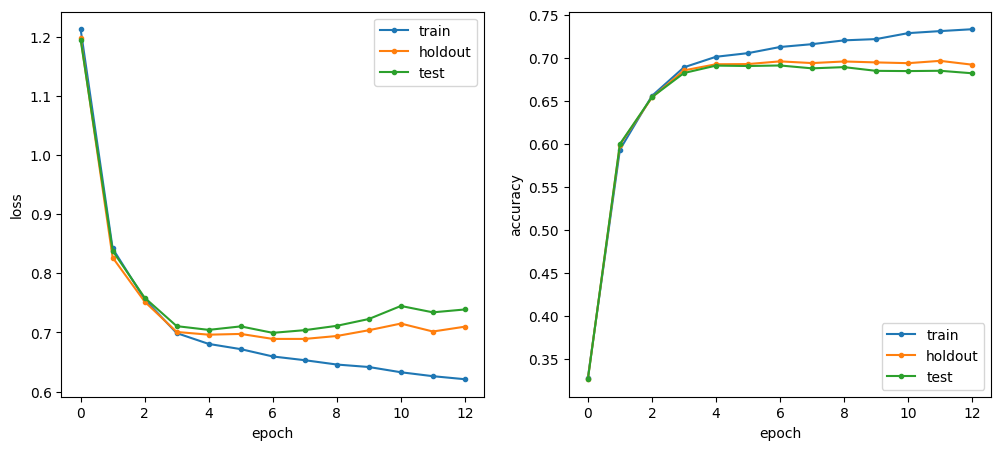

In [39]:
# create the model
model = TransformerModel(model_params).to(device)

# keep track of train, holdout, and test loss and accuracy over epochs for plotting
all_loss = {}
all_accuracy = {}
for k, dataloader in zip(['train', 'holdout', 'test'], [train_dataloader, holdout_dataloader, test_dataloader]):
    all_loss[k], all_accuracy[k] = compute_loss_and_accuracy(dataloader, model, device)
    all_loss[k] = [all_loss[k]]  # convert to list so we can append epoch losses
    all_accuracy[k] = [all_accuracy[k]] 

# initialize the optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=model_params['learning_rate'],
                              weight_decay=model_params['weight_decay'])

# initialize the learning rate scheduler if specified
if model_params['scheduler_type'] == 'OneCycleLR':
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        **lr_scheduler_params,
        optimizer=optimizer,
        total_steps=model_params['n_epochs'] * len(train_dataloader),
    )
elif model_params['scheduler_type'] == 'CosineAnnealingLR':
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(**lr_scheduler_params, optimizer=optimizer)
elif model_params['scheduler_type'] is None:
    scheduler = None
else:
    raise ValueError(f"Unsupported scheduler type: {model_params['scheduler_type']}")

# main training loop
best_holdout_loss = all_loss['holdout'][0]
best_epoch = 0
epochs_without_improvement = 0
best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
patience = model_params['early_stopping_patience']
total = model_params['n_epochs'] * len(train_dataloader)
pbar = tqdm(total=total)


print(f"Before training: train loss: {all_loss['train'][-1]:.4f}, train acc: {all_accuracy['train'][-1]:.4f}, holdout loss: {all_loss['holdout'][-1]:.4f}, holdout acc: {all_accuracy['holdout'][-1]:.4f}")

# iterate over epochs
for epoch in range(model_params['n_epochs']):
    # iterate over batches
    for xb, yb in train_dataloader:
        xb = batch_to_device(xb, device)
        yb = yb.to(device)

        logits, loss = model(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        if scheduler is not None:
            scheduler.step()
        lr = optimizer.param_groups[0]['lr']
        pbar.update(1)
        pbar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{lr:.2e}")

    # compute the loss on the train, holdout, and test sets at the end of the epoch for monitoring
    for k, dataloader in zip(['train', 'holdout', 'test'], [train_dataloader, holdout_dataloader, test_dataloader]):
        loss_curr, acc_curr = compute_loss_and_accuracy(dataloader, model, device)
        all_loss[k].append(loss_curr)
        all_accuracy[k].append(acc_curr)
    print(f"Epoch {epoch+1}/{model_params['n_epochs']}: train loss: {all_loss['train'][-1]:.4f}, train acc: {all_accuracy['train'][-1]:.4f}, holdout loss: {all_loss['holdout'][-1]:.4f}, holdout acc: {all_accuracy['holdout'][-1]:.4f}")

    # keep the best holdout checkpoint and stop once the holdout loss stops improving
    if all_loss['holdout'][-1] < best_holdout_loss:
        best_holdout_loss = all_loss['holdout'][-1]
        best_epoch = epoch + 1
        epochs_without_improvement = 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping after epoch {epoch+1}: no holdout improvement for {patience} epochs.")
            break

pbar.close()

model.load_state_dict(best_state)
print(f"Best holdout checkpoint: epoch {best_epoch}")
for k in ['train', 'holdout', 'test']:
    print(f"{k} loss: {all_loss[k][best_epoch]:.4f}, {k} accuracy: {all_accuracy[k][best_epoch]:.4f}")

# plot the train and holdout loss curves over epochs
fig, ax = plt.subplots(1,2, figsize=(12, 5))
for k in ['train', 'holdout', 'test']:
    ax[0].plot(all_loss[k], '.-', label=k)
    ax[1].plot(all_accuracy[k], '.-', label=k)
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('loss')
ax[0].legend()
ax[1].set_xlabel('epoch')
ax[1].set_ylabel('accuracy')
ax[1].legend()

### Evaluation

Humans:
  v2:4f581cdb-169f-4410-baec-b862aa731de6: 1.000
  v2:55402ef8-01ba-4792-b74d-0b72df12a806: 1.000
  v2:6a156fd9-b164-4b24-9a62-70fd9c6ad078: 1.000
  v2:1fe09717-deab-4411-85f2-92cbca8bdeed: 1.000
  v2:71b9071c-357f-4067-b985-6f3bd55e5d96: 1.000
  v2:81ca618e-ef3c-4769-878f-de0dda8387a2: 1.000
  v2:f1c9505b-9679-44f1-ab77-ef90857bb16e: 1.000
  v2:352fa34b-d5b4-4a35-832e-e9365fd3dd76: 1.000
  v2:cf46ccdb-54ca-4e92-b439-27bfc248f825: 1.000
  v2:9d21b1e7-bcce-44ef-b8d4-9bb8f42b9ed1: 1.000
  v2:643954c0-b7e2-4f5f-8ae7-50c335731299: 1.000
  v2:f61a51ea-8990-4280-926c-41251ade9764: 1.000
  v2:69743815-0d5d-4905-b36b-a998417c6aa1: 1.000
  v2:89134181-aa27-4b20-86db-7012d6c09a85: 1.000
  v2:515a8eed-ef10-4686-a618-17b23bc3f86a: 1.000
  v2:6c6c787a-5e80-4818-98f0-c0d1c0cb33c5: 1.000
  v2:cc8d8833-9f52-42ad-9bba-822fe32831ce: 1.000
  v2:32643f0f-d3c8-4106-9158-ea7fb545a723: 1.000
  v2:9470616d-c469-4a9c-a296-a422098014e2: 1.000
  v2:3d5cc41c-11f1-4260-89d1-5a3dc3d9fc2d: 1.000
  v2:bcfa93a

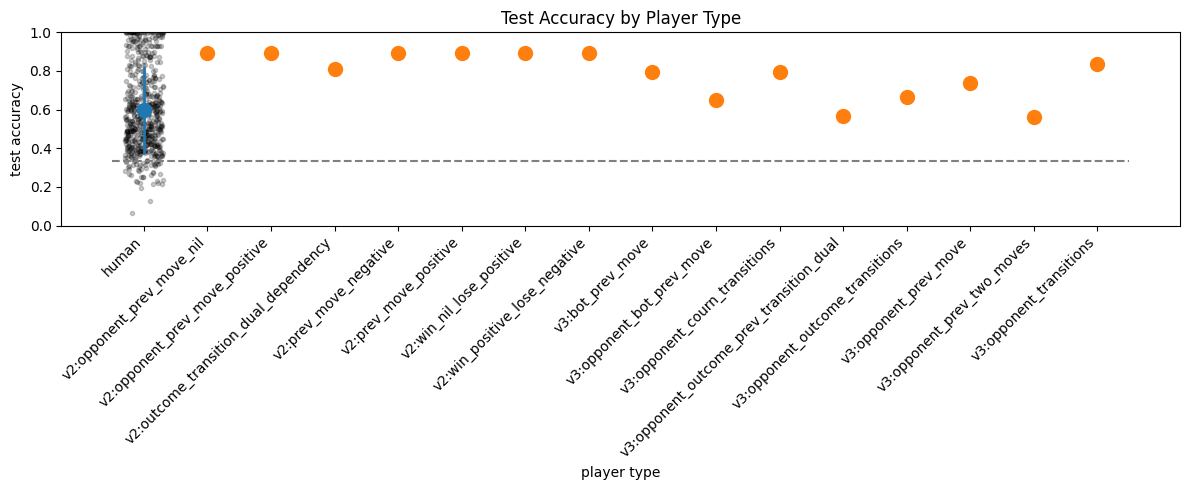

In [ ]:
def compute_test_accuracy_by_player_id(dataloader, dataset, model, device):
    """Compute test accuracy for each self player id in the dataset."""
    total_correct = defaultdict(int)
    total_count = defaultdict(int)

    was_training = model.training
    model.eval()
    with torch.no_grad():
        for xb, yb in dataloader:
            xb_device = batch_to_device(xb, device)
            yb_device = yb.to(device)

            logits, _ = model(xb_device, yb_device)

            pred = logits.argmax(dim=-1).cpu()   # (B, L)
            target = yb.argmax(dim=-1).cpu()     # (B, L)

            # column 0 is always the "self" player whose move we are predicting
            self_player_idx = xb['player_ids'][:, 0].cpu().numpy()

            for b, player_idx in enumerate(self_player_idx):
                player_id = dataset.index_to_player_id[int(player_idx)]
                total_correct[player_id] += (pred[b] == target[b]).sum().item()
                total_count[player_id] += target[b].numel()

    if was_training:
        model.train()

    return {
        player_id: total_correct[player_id] / total_count[player_id]
        for player_id in total_count
    }

acc_by_player_id = compute_test_accuracy_by_player_id(test_dataloader, test_dataset, model, device)

# split into humans and bots
human_points = []
bot_points = {}

for player_id, acc in acc_by_player_id.items():
    if player_id.startswith('bot:'):
        bot_type = player_id[len('bot:'):]   # e.g. v2:prev_move_positive
        bot_points[bot_type] = acc
    else:
        human_points.append((player_id, acc))

bot_types = sorted(bot_points.keys())
x_labels = ['human'] + bot_types
x_pos = {label: i for i, label in enumerate(x_labels)}

fig, ax = plt.subplots(figsize=(12, 5))

# one dot per human, jittered horizontally
x_human = x_pos['human'] + np.random.uniform(-0.3, 0.3, size=len(human_points))
y_human = [acc for _, acc in human_points]
ax.plot(x_human, y_human, 'k.', alpha=0.2, label='humans')
# plot mean and standard deviation for humans
mu = np.mean(y_human)
sig = np.std(y_human)
ax.plot(x_pos['human'], mu, 'o', color='C0', label='human mean', ms=10)
ax.plot([x_pos['human'], x_pos['human']], [mu - sig, mu + sig], '-', color='C0', lw=2, label='human std')

# one dot per bot algorithm
for bot_type in bot_types:
    ax.plot(x_pos[bot_type], bot_points[bot_type], 'o', color='C1', label=bot_type, ms=10)

ax.hlines(1/len(NAMES), -0.5, len(x_labels)-0.5, colors='gray', linestyles='dashed', label='chance')
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45, ha='right')
ax.set_xlabel('player type')
ax.set_ylabel('test accuracy')
ax.set_ylim(0, 1)
ax.set_title('Test Accuracy by Player Type')
fig.tight_layout()

print('Humans:')
for player_id, acc in sorted(human_points, key=lambda x: x[1], reverse=True):
    print(f'  {player_id}: {acc:.3f}')

print('\nBots:')
for bot_type in bot_types:
    print(f'  {bot_type}: {bot_points[bot_type]:.3f}')

## 7. Exercises

1. Compare to models more complicated than logistic regression and simpler than transformers. 
2. Try to make the transformer perform better.
3. Play against a partner and create a new dataset. Retrain the transformer on this. Play against the transformer. 
4. Interpretability: how do we figure out what the transformer is doing? 
  - Think of some known strategies of humans in rock-paper-scissors, e.g. win-stay, lose-shift
  - Try to find a representation of that strategy in the network
5. How well can an LLM do this? Prompt ChatGPT, Claude, Qwen etc. with something like: 
"I am playing rock-paper-scissors. Here is the sequence of moves me and my opponent have made (me, opponent):
(rock, scissors), (scissors, paper), \[etc.\]
What will my opponent play next?" 